# Block 1: Mount đến Google Drive và Import file

In [ ]:
# @title
from pathlib import Path
import pandas as pd

# 1. Tự động Mount Google Drive nếu đang chạy trên Google Colab
try:
    from google.colab import drive

    if not Path("/content/drive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass  # Đang chạy ở máy local (Jupyter Notebook / VS Code)

# 2. Cấu hình hiển thị Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# 3. Cấu hình đường dẫn
folder_path = "/content/drive/MyDrive/ITB Dataset/"
DATA_DIR = Path(folder_path)

file_monthly_path = DATA_DIR / "consumer_financial_health_engagement_2025.csv"
file_trans_path = DATA_DIR / "consumer_transactions_2025.csv"

# Kiểm tra đường dẫn tồn tại trước khi load
if not file_monthly_path.exists() or not file_trans_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file tại '{DATA_DIR}'. Vui lòng kiểm tra lại tên thư mục trên Drive!"
    )

print("Bắt đầu nạp dữ liệu...")

# 4. Đọc bảng Monthly
df_monthly = pd.read_csv(
    file_monthly_path,
    dtype={"consumer_id": str},
    parse_dates=["analysis_month"],
)

# 5. Đọc bảng Transactions Chi tiết
df_trans = pd.read_csv(
    file_trans_path,
    dtype={
        "consumer_id": str,
        "transaction_id": str,
        "merchant_id": str,
        "administrative_code": str,
    },
    parse_dates=["activity_datetime"],
)

# 6. Thông tin tổng quan và kiểm tra dữ liệu
print(f"✓ df_monthly: {len(df_monthly):,} dòng | {df_monthly.shape[1]} cột")
print(f"✓ df_trans:   {len(df_trans):,} dòng | {df_trans.shape[1]} cột\n")

print("--- Bảng Monthly (3 dòng đầu) ---")
display(df_monthly.head(3))

print("\n--- Bảng Transactions (3 dòng đầu) ---")
display(df_trans.head(3))

Bắt đầu nạp dữ liệu...
✓ df_monthly: 10,992 dòng | 30 cột
✓ df_trans:   1,852,394 dòng | 28 cột

--- Bảng Monthly (3 dòng đầu) ---


,consumer_id,analysis_month,age,gender,occupation,province_city,monthly_income_vnd,credit_limit_vnd,opening_balance_vnd,ending_balance_vnd,total_spend_vnd,essential_spend_vnd,discretionary_spend_vnd,online_spend_vnd,transaction_count,active_transaction_days,average_transaction_value_vnd,category_diversity,essential_spend_ratio,discretionary_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,transaction_recency_days,spending_volatility,engagement_score,financial_health_score,engagement_segment,financial_health_segment,next_month_low_health_flag
0,KH00100010,2025-01-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,1003930000,3780600000,501965000,1065133000,440762000,138355000,302407000,69095000,169,31,2608059,14,0.31,0.69,0.16,0.44,0.12,0,0.98,77.40,74.40,Tương tác cao,Ổn định,0.00
1,KH00100010,2025-02-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,961510000,3780600000,1065133000,1627173000,399470000,150487000,248983000,58800000,182,28,2194890,14,0.38,0.62,0.15,0.42,0.11,0,0.89,77.10,76.30,Tương tác cao,Ổn định,0.00
2,KH00100010,2025-03-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,916740000,3780600000,1627173000,2029964000,513949000,180684000,333265000,95894000,212,30,2424288,14,0.35,0.65,0.19,0.56,0.14,0,0.97,79.00,71.20,Tương tác cao,Ổn định,0.00



--- Bảng Transactions (3 dòng đầu) ---


,transaction_id,activity_datetime,consumer_id,customer_name,gender,date_of_birth,age_at_transaction,occupation,street_address,ward_commune,province_city,administrative_code,customer_latitude,customer_longitude,local_population,merchant_id,merchant_name,spending_category,spend_amount_vnd,merchant_latitude,merchant_longitude,transaction_channel,payment_method,online_transaction_flag,essential_spending_flag,transaction_month,transaction_day_of_week,transaction_hour
0,GD20250000000001,2025-01-01 00:00:18,KH00102405,Lý Ngọc Nga,Nữ,1993-03-09,31,Nhà tâm lý học tư vấn,Số 372 đường Lê Lai,Tân Lập,Đắk Lắk,66661,12.66,108.20,53297,M00515,Dịch vụ trực tuyến Tân Phát,Dịch vụ trực tuyến khác,124000,13.99,107.99,E-commerce,Ví điện tử,1,0,1,2,0
1,GD20250000000002,2025-01-01 00:00:44,KH00118490,Trịnh Minh Lan,Nữ,1983-06-21,41,Giáo viên giáo dục đặc biệt,Số 289 đường Phạm Ngũ Lão,Bắc Sơn,Lạng Sơn,20965,21.80,106.71,19910,M00242,Siêu thị Trường Sơn,Siêu thị và tạp hóa tại cửa hàng,2681000,20.88,106.65,POS,Thẻ tín dụng,0,1,1,2,0
2,GD20250000000003,2025-01-01 00:00:51,KH00109845,Đào Anh Vũ,Nam,1967-01-19,57,Cán bộ bảo tồn thiên nhiên,Số 36 đường Phan Đình Phùng,Gò Vấp,Thành phố Hồ Chí Minh,79017,10.81,106.61,403078,M00391,Nhà hát Phú Quý,Giải trí,5503000,10.80,106.63,POS,Thẻ ghi nợ,0,0,1,2,0


# Block 2: Câu 1.1


In [ ]:
# @title
import numpy as np
import pandas as pd

# Giả sử bạn đã load df_monthly từ file consumer_financial_health_engagement_2025.csv
# Bước 1: Chuẩn hóa cột tháng thành chuỗi YYYY-MM
df_monthly["month_str"] = pd.to_datetime(
    df_monthly["analysis_month"]
).dt.strftime("%Y-%m")

# Bước 2: Tổng hợp dữ liệu theo từng tháng
monthly_summary = (
    df_monthly.groupby("month_str")
    .agg(
        total_spend=("total_spend_vnd", "sum"),
        total_txns=("transaction_count", "sum"),
    )
    .reset_index()
)

# Tính giá trị trung bình mỗi giao dịch (ATV / Ticket Size) theo tháng
monthly_summary["ticket_size_vnd"] = (
    monthly_summary["total_spend"] / monthly_summary["total_txns"]
)

# Tính tỷ trọng chi tiêu của từng tháng so với tổng cả năm (% of annual spend)
annual_spend = monthly_summary["total_spend"].sum()
monthly_summary["pct_of_annual_spend"] = (
    monthly_summary["total_spend"] / annual_spend
) * 100

# Bước 3: Xác định tháng chi tiêu cao nhất (Peak) và thấp nhất (Trough)
peak_month = monthly_summary.loc[monthly_summary["total_spend"].idxmax()]
lowest_month = monthly_summary.loc[monthly_summary["total_spend"].idxmin()]

# Các chỉ số so sánh giữa đỉnh (Peak) và đáy (Lowest)
spend_diff_vnd = peak_month["total_spend"] - lowest_month["total_spend"]
spend_pct_diff = (
    (peak_month["total_spend"] - lowest_month["total_spend"])
    / lowest_month["total_spend"]
) * 100

txn_growth_pct = (
    (peak_month["total_txns"] - lowest_month["total_txns"])
    / lowest_month["total_txns"]
) * 100
ticket_growth_pct = (
    (peak_month["ticket_size_vnd"] - lowest_month["ticket_size_vnd"])
    / lowest_month["ticket_size_vnd"]
) * 100

# Hiển thị bảng tổng hợp các tháng
print("BẢNG TỔNG HỢP CHI TIÊU THEO THÁNG (2025)")
display(
    monthly_summary.style.format(
        {
            "total_spend": "{:,.0f} VND",
            "total_txns": "{:,.0f}",
            "ticket_size_vnd": "{:,.0f} VND",
            "pct_of_annual_spend": "{:.2f}%",
        }
    )
)

other_months = monthly_summary[
    monthly_summary["month_str"] != peak_month["month_str"]
]
avg_spend_11_months = other_months["total_spend"].mean()

# Mức vượt trội của tháng đỉnh so với mức bình quân 11 tháng
pct_above_average = (
    (peak_month["total_spend"] - avg_spend_11_months) / avg_spend_11_months
) * 100

# In kết quả trả lời câu hỏi
print(f"1. THÁNG CHI TIÊU CAO NHẤT (Peak Month): {peak_month['month_str']}")
print(f"   - Tổng chi tiêu: {peak_month['total_spend']:,.0f} VND")
print(
    f"   - Tỷ trọng so với cả năm: {peak_month['pct_of_annual_spend']:.2f}% của Annual Spend - Cao hơn mức chi tiêu bình quân của 11 tháng còn lại: +{pct_above_average:.2f}% (gấp {peak_month['total_spend']/avg_spend_11_months:.2f} lần)"
)

print(f"\n2. THÁNG CHI TIÊU THẤP NHẤT (Lowest Month): {lowest_month['month_str']}")
print(f"   - Tổng chi tiêu: {lowest_month['total_spend']:,.0f} VND")
print(
    f"   - Tỷ trọng so với cả năm: {lowest_month['pct_of_annual_spend']:.2f}% của Annual Spend"
)

print("\n3. SO SÁNH GIỮA THÁNG ĐỈNH VÀ THÁNG ĐÁY:")
print(f"   - Chênh lệch giá trị tuyệt đối: {spend_diff_vnd:,.0f} VND")
print(
    f"   - Tháng đỉnh cao hơn tháng đáy: +{spend_pct_diff:.2f}% (gấp {peak_month['total_spend']/lowest_month['total_spend']:.2f} lần)"
)

print("\n4. ĐỘNG LỰC TĂNG TRƯỞNG (Driver Analysis):")
print(
    f"   - Tăng trưởng số lượng giao dịch (Txn Count): +{txn_growth_pct:.2f}%"
)
ticket_diff_vnd = peak_month["ticket_size_vnd"] - lowest_month["ticket_size_vnd"]
print(
    f"   - Tăng trưởng giá trị mỗi giao dịch (Ticket Size): +{ticket_growth_pct:.2f}% - Thay đổi trung bình: {ticket_diff_vnd:,.0f} VND/giao dịch"
)

if txn_growth_pct > ticket_growth_pct:
    primary_driver = "SỐ LƯỢNG GIAO DỊCH (Transaction Count / Tần suất quẹt thẻ)"
else:
    primary_driver = (
        "GIÁ TRỊ MỖI ĐƠN HÀNG (Ticket Size / Giá trị giao dịch lớn)"
    )

print(f"   => Động lực tăng trưởng chính: {primary_driver}")

BẢNG TỔNG HỢP CHI TIÊU THEO THÁNG (2025)


,month_str,total_spend,total_txns,ticket_size_vnd,pct_of_annual_spend
0,2025-01,"185,570,433,000 VND","104,727","1,771,945 VND",5.72%
1,2025-02,"174,365,111,000 VND","97,657","1,785,485 VND",5.37%
2,2025-03,"254,750,003,000 VND","143,789","1,771,693 VND",7.85%
3,2025-04,"236,320,934,000 VND","134,970","1,750,915 VND",7.28%
4,2025-05,"257,623,444,000 VND","146,875","1,754,032 VND",7.94%
5,2025-06,"305,572,891,000 VND","173,869","1,757,489 VND",9.42%
6,2025-07,"299,556,013,000 VND","172,444","1,737,121 VND",9.23%
7,2025-08,"304,519,084,000 VND","176,118","1,729,063 VND",9.39%
8,2025-09,"246,520,864,000 VND","140,185","1,758,540 VND",7.60%
9,2025-10,"243,005,639,000 VND","138,106","1,759,559 VND",7.49%


1. THÁNG CHI TIÊU CAO NHẤT (Peak Month): 2025-12
   - Tổng chi tiêu: 488,032,709,000 VND
   - Tỷ trọng so với cả năm: 15.04% của Annual Spend - Cao hơn mức chi tiêu bình quân của 11 tháng còn lại: +94.75% (gấp 1.95 lần)

2. THÁNG CHI TIÊU THẤP NHẤT (Lowest Month): 2025-02
   - Tổng chi tiêu: 174,365,111,000 VND
   - Tỷ trọng so với cả năm: 5.37% của Annual Spend

3. SO SÁNH GIỮA THÁNG ĐỈNH VÀ THÁNG ĐÁY:
   - Chênh lệch giá trị tuyệt đối: 313,667,598,000 VND
   - Tháng đỉnh cao hơn tháng đáy: +179.89% (gấp 2.80 lần)

4. ĐỘNG LỰC TĂNG TRƯỞNG (Driver Analysis):
   - Tăng trưởng số lượng giao dịch (Txn Count): +187.33%
   - Tăng trưởng giá trị mỗi giao dịch (Ticket Size): +-2.59% - Thay đổi trung bình: -46,226 VND/giao dịch
   => Động lực tăng trưởng chính: SỐ LƯỢNG GIAO DỊCH (Transaction Count / Tần suất quẹt thẻ)
BẢNG TỔNG HỢP CHI TIÊU THEO THÁNG (2025)


,month_str,total_spend,total_txns,ticket_size_vnd,pct_of_annual_spend
0,2025-01,"185,570,433,000 VND","104,727","1,771,945 VND",5.72%
1,2025-02,"174,365,111,000 VND","97,657","1,785,485 VND",5.37%
2,2025-03,"254,750,003,000 VND","143,789","1,771,693 VND",7.85%
3,2025-04,"236,320,934,000 VND","134,970","1,750,915 VND",7.28%
4,2025-05,"257,623,444,000 VND","146,875","1,754,032 VND",7.94%
5,2025-06,"305,572,891,000 VND","173,869","1,757,489 VND",9.42%
6,2025-07,"299,556,013,000 VND","172,444","1,737,121 VND",9.23%
7,2025-08,"304,519,084,000 VND","176,118","1,729,063 VND",9.39%
8,2025-09,"246,520,864,000 VND","140,185","1,758,540 VND",7.60%
9,2025-10,"243,005,639,000 VND","138,106","1,759,559 VND",7.49%


1. THÁNG CHI TIÊU CAO NHẤT (Peak Month): 2025-12
   - Tổng chi tiêu: 488,032,709,000 VND
   - Tỷ trọng so với cả năm: 15.04% của Annual Spend - Cao hơn mức chi tiêu bình quân của 11 tháng còn lại: +94.75% (gấp 1.95 lần)

2. THÁNG CHI TIÊU THẤP NHẤT (Lowest Month): 2025-02
   - Tổng chi tiêu: 174,365,111,000 VND
   - Tỷ trọng so với cả năm: 5.37% của Annual Spend

3. SO SÁNH GIỮA THÁNG ĐỈNH VÀ THÁNG ĐÁY:
   - Chênh lệch giá trị tuyệt đối: 313,667,598,000 VND
   - Tháng đỉnh cao hơn tháng đáy: +179.89% (gấp 2.80 lần)

4. ĐỘNG LỰC TĂNG TRƯỞNG (Driver Analysis):
   - Tăng trưởng số lượng giao dịch (Txn Count): +187.33%
   - Tăng trưởng giá trị mỗi giao dịch (Ticket Size): +-2.59% - Thay đổi trung bình: -46,226 VND/giao dịch
   => Động lực tăng trưởng chính: SỐ LƯỢNG GIAO DỊCH (Transaction Count / Tần suất quẹt thẻ)


# EXECUTIVE SUMMARY & FINDINGS: PHÂN TÍCH TÍNH MÙA VỤ (2025)


## 1. Key Findings

* **Phân phối mùa vụ lệch cực độ:**
  * Chi tiêu chạm đỉnh vào **2025-12** đạt **488,032,709,000 VND** (chiếm **15.04%** tổng chi tiêu cả năm) và chạm đáy vào **2025-02** với **174,365,111,000 VND** (chiếm **5.37%**).
  * Tháng đỉnh cao hơn tháng đáy **+179.89%** (gấp **2.80 lần**, chênh lệch tuyệt đối **313,667,598,000 VND**) và cao hơn mức chi tiêu bình quân của 11 tháng còn lại **+94.75%** (gấp **1.95 lần**).

* **Động lực tăng trưởng chính là sức tăng của tần suất:**
  * Tăng trưởng chi tiêu được dẫn dắt **100% bởi số lượng giao dịch (Transaction Count)** với mức tăng vọt **+187.33%** so với tháng đáy.
  * Quy mô đơn hàng trung bình **(Ticket Size) không tăng trưởng mà đi ngang/giảm nhẹ**: biến động **-2.59%** (giảm tuyệt đối **-46,226 VND/giao dịch**).

* **Bản chất hành vi người tiêu dùng:**
  * **Hành vi chi tiêu High-frequency Micro-spending:** Đỉnh chi tiêu cuối năm không đến từ việc mua sắm các đơn hàng giá trị cao tập trung (Big-ticket purchases), mà hình thành từ việc người dùng phát sinh các giao dịch nhỏ lẻ với tần suất liên tục.
  * **Hiệu ứng thâm nhập thanh toán số (Cashless Micro-transactions):** Mức chi tiêu trung bình trên mỗi giao dịch giữ ở mức thấp kết hợp cùng lượng giao dịch tăng gấp gần 3 lần cho thấy khách hàng chuyển dịch sang thanh toán không dùng tiền mặt (thẻ, app, QR) cho các nhu cầu tiêu dùng thường nhật nhỏ nhất trong mùa lễ hội/cuối năm.

---

## 2. CÁC VẤN ĐỀ CẦN PHÂN TÍCH BREAKDOWN ĐỂ LÀM RÕ VẤN ĐỀ

Để trả lời câu hỏi *"Tại sao tần suất giao dịch lại bùng nổ trong khi giá trị đơn hàng suy giảm?"*, cần thực hiện các phân tích đào sâu dựa trên các trường dữ liệu hiện có:

### [ ] Task 1: Phân rã theo Danh mục Chi tiêu (Category Breakdown)
* **Mục tiêu:** Xác định danh mục nào chịu trách nhiệm chính kéo tụt Ticket Size và đẩy vọt Transaction Count.
* **Biến số cần bóc tách:**
  * Bảng `consumer_transaction_2025`: `spending_category`, `essential_spending_flag`, `spend_amount_vnd`.
  * Bảng `consumer_financial_health_engagement_2025`: Tỷ lệ giữa `essential_spend_vnd` vs `discretionary_spend_vnd`, biến động `category_diversity`.

### [ ] Task 2: Phân tích Kênh & Phương thức Thanh toán (Channel & Payment Adoption)
* **Mục tiêu:** Kiểm chứng giả thuyết chuyển dịch sang thanh toán số cho các đơn hàng giá trị nhỏ.
* **Biến số cần bóc tách:**
  * Bảng `consumer_transaction_2025`: `transaction_channel` (POS, Mobile App, QR, E-commerce), `payment_method`, `online_transaction_flag`.
  * Đánh giá tỷ trọng `online_spend_ratio` trong tháng 12 so với tháng 2.

### [ ] Task 3: Đánh giá Đòn bẩy & Tác động Sức khỏe Tài chính (Credit Leverage & Financial Stress)
* **Mục tiêu:** Đo lường mức độ rủi ro tín dụng khi chi tiêu tăng gấp 2.8 lần.
* **Biến số cần bóc tách:**
  * Bảng `consumer_financial_health_engagement_2025`: `credit_utilization_ratio`, `spend_to_income_ratio`, `ending_balance_vnd`.
  * Xu hướng dịch chuyển phân khúc sức khỏe tài chính: `financial_health_score`, `financial_health_segment`, `next_month_low_health_flag`.

### [ ] Task 4: Phân khúc Khách hàng Dẫn dắt (Cohort & Demographic Contribution)
* **Mục tiêu:** Xác định nhóm đối tượng đóng góp tỷ trọng chính vào mức tăng 313.67 tỷ VND.
* **Biến số cần bóc tách:**
  * `age` (nhóm tuổi), `occupation` (nghề nghiệp), `province_city` (địa bàn đô thị vs tỉnh lẻ).
  * Mức độ hoạt động liên tục: `active_transaction_days`, `transaction_recency_days`.

# Block 3.1: Breakdown analysis cho câu 1.1

# Block 3: Câu 1.2


In [ ]:
# @title
import numpy as np
import pandas as pd

# Giả sử df_monthly đã được nạp từ tập dữ liệu consumer_financial_health_engagement_2025.csv

# =============================================================================
# BƯỚC 1: PHÂN NHÓM KHÁCH HÀNG DỰA TRÊN ĐIỂM SỨC KHỎE TÀI CHÍNH
# =============================================================================
conditions = [
    df_monthly["financial_health_score"] < 40,
    df_monthly["financial_health_score"] >= 80,
]
cohort_names = ["Stressed (< 40)", "Healthy (>= 80)"]

df_comp = df_monthly.copy()
df_comp["health_group"] = np.select(conditions, cohort_names, default=None)

# Lọc lấy hai nhóm đối tượng cần so sánh
df_analyzed = df_comp.dropna(subset=["health_group"]).copy()

# =============================================================================
# BƯỚC 2: TÍNH TOÁN CÁC CHỈ SỐ CƠ CẤU CHI TIÊU & ĐÒN BẨY
# =============================================================================
# 1. Tổng hợp theo nhóm
summary = (
    df_analyzed.groupby("health_group")
    .agg(
        total_records=("consumer_id", "count"),
        unique_customers=("consumer_id", "nunique"),
        total_spend=("total_spend_vnd", "sum"),
        sum_essential=("essential_spend_vnd", "sum"),
        sum_discretionary=("discretionary_spend_vnd", "sum"),
        mean_essential_ratio=("essential_spend_ratio", "mean"),
        mean_discretionary_ratio=("discretionary_spend_ratio", "mean"),
        mean_spend_to_income=("spend_to_income_ratio", "mean"),
        mean_credit_utilization=("credit_utilization_ratio", "mean"),
    )
    .reset_index()
)

# 2. Tính tỷ trọng chi tiêu tổng thể (Macro / Aggregated level)
summary["agg_essential_pct"] = (
    summary["sum_essential"] / summary["total_spend"]
) * 100
summary["agg_discretionary_pct"] = (
    summary["sum_discretionary"] / summary["total_spend"]
) * 100

# 3. Chuẩn hóa tỷ lệ trung bình cấp độ vi mô (Micro / Individual customer mean)
summary["mean_essential_pct"] = summary["mean_essential_ratio"] * 100
summary["mean_discretionary_pct"] = summary["mean_discretionary_ratio"] * 100


# BƯỚC 3: HIỂN THỊ KẾT QUẢ ĐỐI CHIẾU

print("BẢNG SO SÁNH CƠ CẤU CHI TIÊU: STRESSED (< 40) VS. HEALTHY (>= 80)")

display(
    summary[
        [
            "health_group",
            "total_records",
            "unique_customers",
            "agg_essential_pct",
            "agg_discretionary_pct",
            "mean_essential_pct",
            "mean_discretionary_pct",
            "mean_spend_to_income",
            "mean_credit_utilization",
        ]
    ].style.format(
        {
            "total_records": "{:,.0f}",
            "unique_customers": "{:,.0f}",
            "agg_essential_pct": "{:.2f}%",
            "agg_discretionary_pct": "{:.2f}%",
            "mean_essential_pct": "{:.2f}%",
            "mean_discretionary_pct": "{:.2f}%",
            "mean_spend_to_income": "{:.2f}",
            "mean_credit_utilization": "{:.2f}%",
        }
    )
)

# Trích xuất biến để in phân tích động
row_stressed = summary[summary["health_group"] == "Stressed (< 40)"].iloc[0]
row_healthy = summary[summary["health_group"] == "Healthy (>= 80)"].iloc[0]

essential_gap = (
    row_stressed["agg_essential_pct"] - row_healthy["agg_essential_pct"]
)
discretionary_gap = (
    row_healthy["agg_discretionary_pct"]
    - row_stressed["agg_discretionary_pct"]
)


print("BÁO CÁO PHÂN TÍCH CHÊNH LỆCH CƠ CẤU NGÂN SÁCH (EXECUTIVE FINDINGS):")

print(f"1. NHÓM CĂNG THẲNG TÀI CHÍNH (Stressed - Score < 40):")
print(
    f"   - Tỷ trọng chi tiêu Thiết yếu (Essential):        {row_stressed['agg_essential_pct']:.2f}%"
)
print(
    f"   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        {row_stressed['agg_discretionary_pct']:.2f}%"
)
print(
    f"   - Hệ số chi tiêu trên thu nhập (Spend/Income):    {row_stressed['mean_spend_to_income']:.2f} lần"
)
print(
    f"   - Tỷ lệ sử dụng hạn mức tín dụng:                 {row_stressed['mean_credit_utilization']:.2f}%"
)

print(f"\n2. NHÓM SỨC KHỎE TÀI CHÍNH TỐT (Healthy - Score >= 80):")
print(
    f"   - Tỷ trọng chi tiêu Thiết yếu (Essential):        {row_healthy['agg_essential_pct']:.2f}%"
)
print(
    f"   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        {row_healthy['agg_discretionary_pct']:.2f}%"
)
print(
    f"   - Hệ số chi tiêu trên thu nhập (Spend/Income):    {row_healthy['mean_spend_to_income']:.2f} lần"
)
print(
    f"   - Tỷ lệ sử dụng hạn mức tín dụng:                 {row_healthy['mean_credit_utilization']:.2f}%"
)

print(f"\n3. KẾT LUẬN VỀ SỰ THAY ĐỔI CƠ CẤU PHÂN BỔ NGÂN SÁCH:")
print(
    f"   - Chênh lệch tỷ trọng Thiết yếu: Nhóm Stressed cao hơn +{essential_gap:.2f}% điểm phần trăm."
)
print(
    f"   - Chênh lệch tỷ trọng Tùy ý:     Nhóm Stressed bị thu hẹp -{discretionary_gap:.2f}% điểm phần trăm."
)
print(
    f"   - Bản chất: Áp lực tài chính ép buộc khách hàng chuyển đổi mô hình từ chi tiêu đa dạng/hưởng thụ"
)
print(
    f"     sang trạng thái 'ngân sách phòng thủ/sinh tồn' (Survival Budgeting), trong đó phần lớn dòng tiền"
)

print(
    f"     khả dụng bị trói chặt vào các khoản chi phí thiết yếu không thể cắt giảm."
)


BẢNG SO SÁNH CƠ CẤU CHI TIÊU: STRESSED (< 40) VS. HEALTHY (>= 80)


,health_group,total_records,unique_customers,agg_essential_pct,agg_discretionary_pct,mean_essential_pct,mean_discretionary_pct,mean_spend_to_income,mean_credit_utilization
0,Healthy (>= 80),475,303,59.46%,40.54%,61.10%,38.90%,0.29,0.08%
1,Stressed (< 40),95,70,28.36%,71.64%,28.83%,71.17%,2.10,0.58%


BÁO CÁO PHÂN TÍCH CHÊNH LỆCH CƠ CẤU NGÂN SÁCH (EXECUTIVE FINDINGS):
1. NHÓM CĂNG THẲNG TÀI CHÍNH (Stressed - Score < 40):
   - Tỷ trọng chi tiêu Thiết yếu (Essential):        28.36%
   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        71.64%
   - Hệ số chi tiêu trên thu nhập (Spend/Income):    2.10 lần
   - Tỷ lệ sử dụng hạn mức tín dụng:                 0.58%

2. NHÓM SỨC KHỎE TÀI CHÍNH TỐT (Healthy - Score >= 80):
   - Tỷ trọng chi tiêu Thiết yếu (Essential):        59.46%
   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        40.54%
   - Hệ số chi tiêu trên thu nhập (Spend/Income):    0.29 lần
   - Tỷ lệ sử dụng hạn mức tín dụng:                 0.08%

3. KẾT LUẬN VỀ SỰ THAY ĐỔI CƠ CẤU PHÂN BỔ NGÂN SÁCH:
   - Chênh lệch tỷ trọng Thiết yếu: Nhóm Stressed cao hơn +-31.10% điểm phần trăm.
   - Chênh lệch tỷ trọng Tùy ý:     Nhóm Stressed bị thu hẹp --31.10% điểm phần trăm.
   - Bản chất: Áp lực tài chính ép buộc khách hàng chuyển đổi mô hình từ chi tiêu đa dạng/hưởng thụ
     sang trạng 

,health_group,total_records,unique_customers,agg_essential_pct,agg_discretionary_pct,mean_essential_pct,mean_discretionary_pct,mean_spend_to_income,mean_credit_utilization
0,Healthy (>= 80),475,303,59.46%,40.54%,61.10%,38.90%,0.29,0.08%
1,Stressed (< 40),95,70,28.36%,71.64%,28.83%,71.17%,2.10,0.58%


BÁO CÁO PHÂN TÍCH CHÊNH LỆCH CƠ CẤU NGÂN SÁCH (EXECUTIVE FINDINGS):
1. NHÓM CĂNG THẲNG TÀI CHÍNH (Stressed - Score < 40):
   - Tỷ trọng chi tiêu Thiết yếu (Essential):        28.36%
   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        71.64%
   - Hệ số chi tiêu trên thu nhập (Spend/Income):    2.10 lần
   - Tỷ lệ sử dụng hạn mức tín dụng:                 0.58%

2. NHÓM SỨC KHỎE TÀI CHÍNH TỐT (Healthy - Score >= 80):
   - Tỷ trọng chi tiêu Thiết yếu (Essential):        59.46%
   - Tỷ trọng chi tiêu Tùy ý (Discretionary):        40.54%
   - Hệ số chi tiêu trên thu nhập (Spend/Income):    0.29 lần
   - Tỷ lệ sử dụng hạn mức tín dụng:                 0.08%

3. KẾT LUẬN VỀ SỰ THAY ĐỔI CƠ CẤU PHÂN BỔ NGÂN SÁCH:
   - Chênh lệch tỷ trọng Thiết yếu: Nhóm Stressed cao hơn +-31.10% điểm phần trăm.
   - Chênh lệch tỷ trọng Tùy ý:     Nhóm Stressed bị thu hẹp --31.10% điểm phần trăm.
   - Bản chất: Áp lực tài chính ép buộc khách hàng chuyển đổi mô hình từ chi tiêu đa dạng/hưởng thụ
     sang trạng 

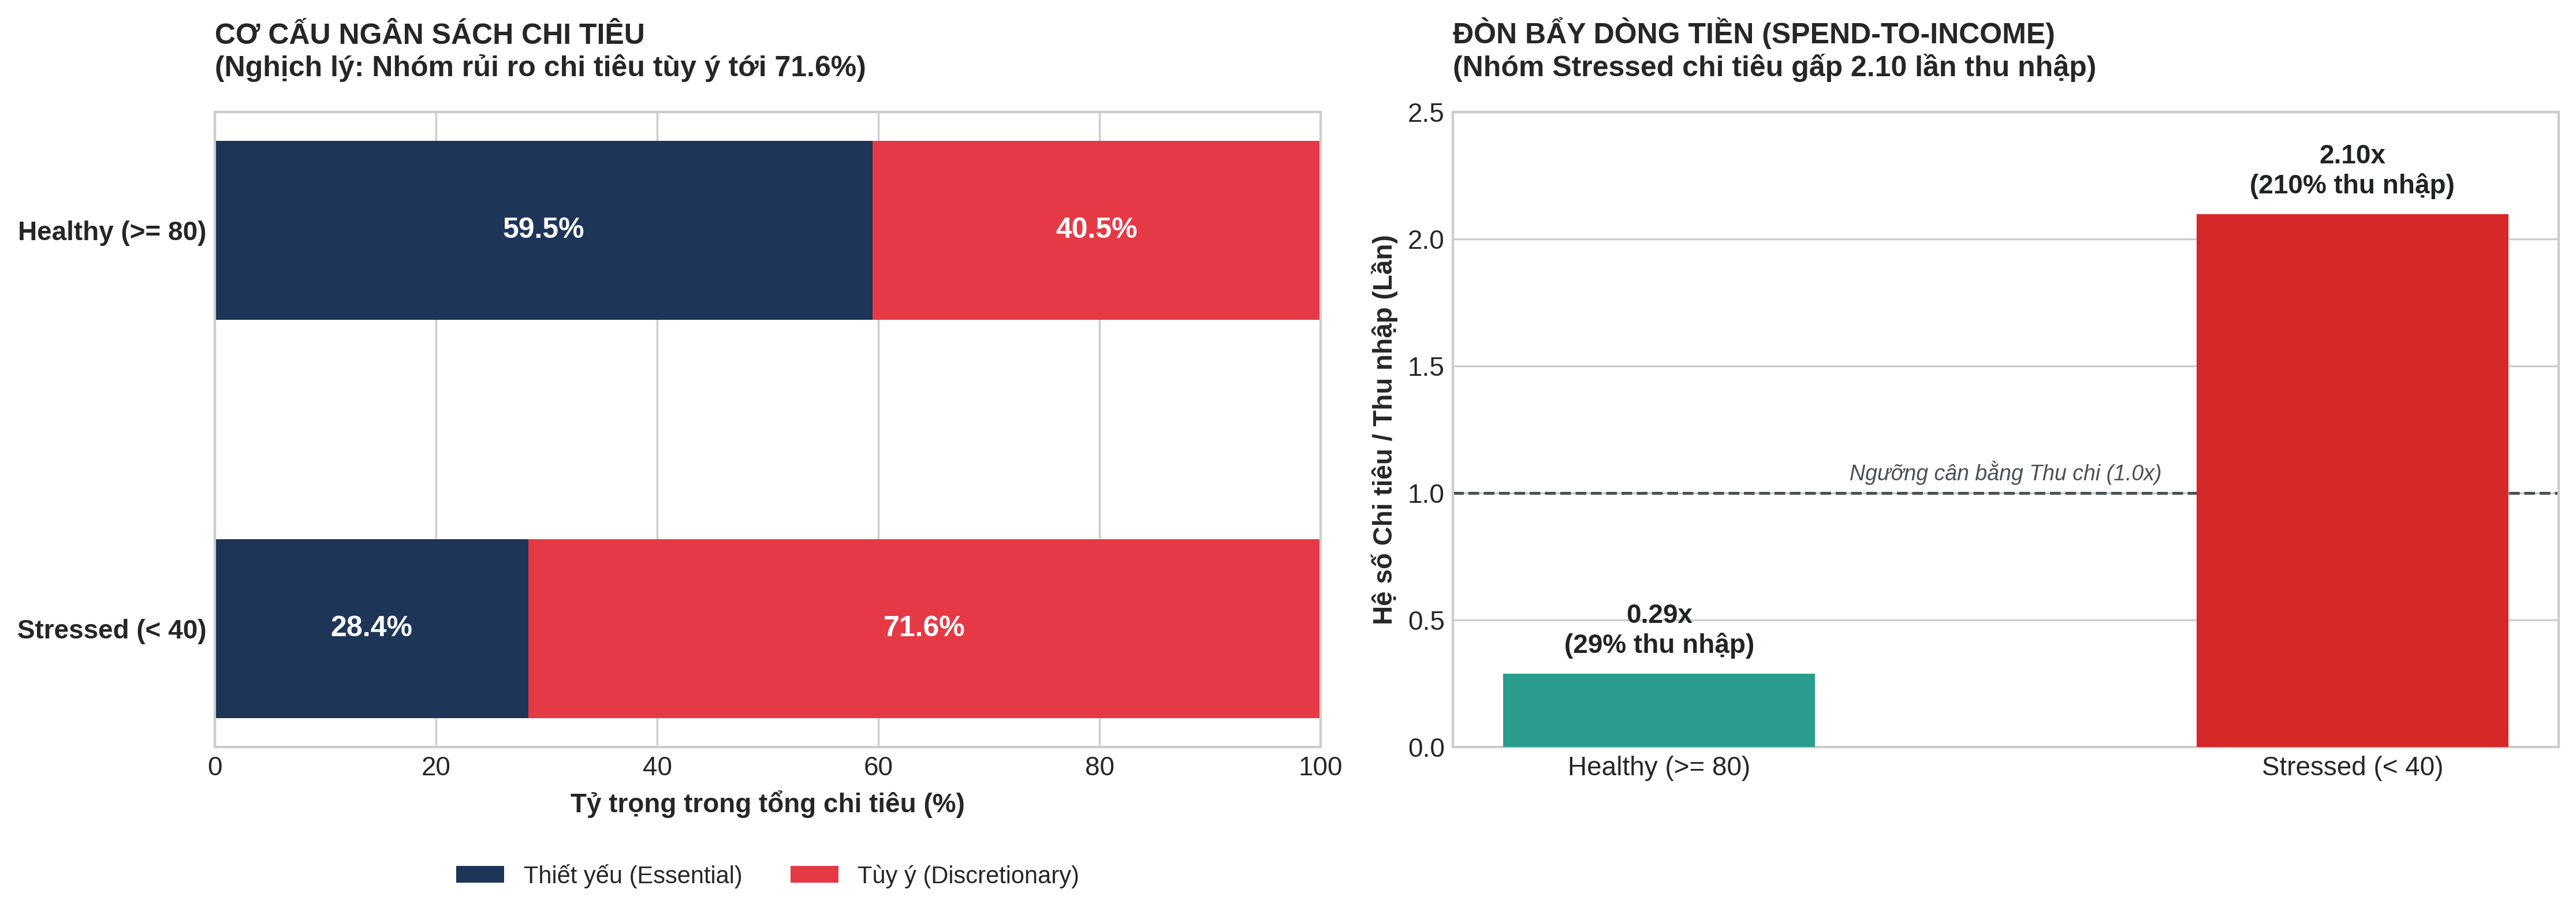

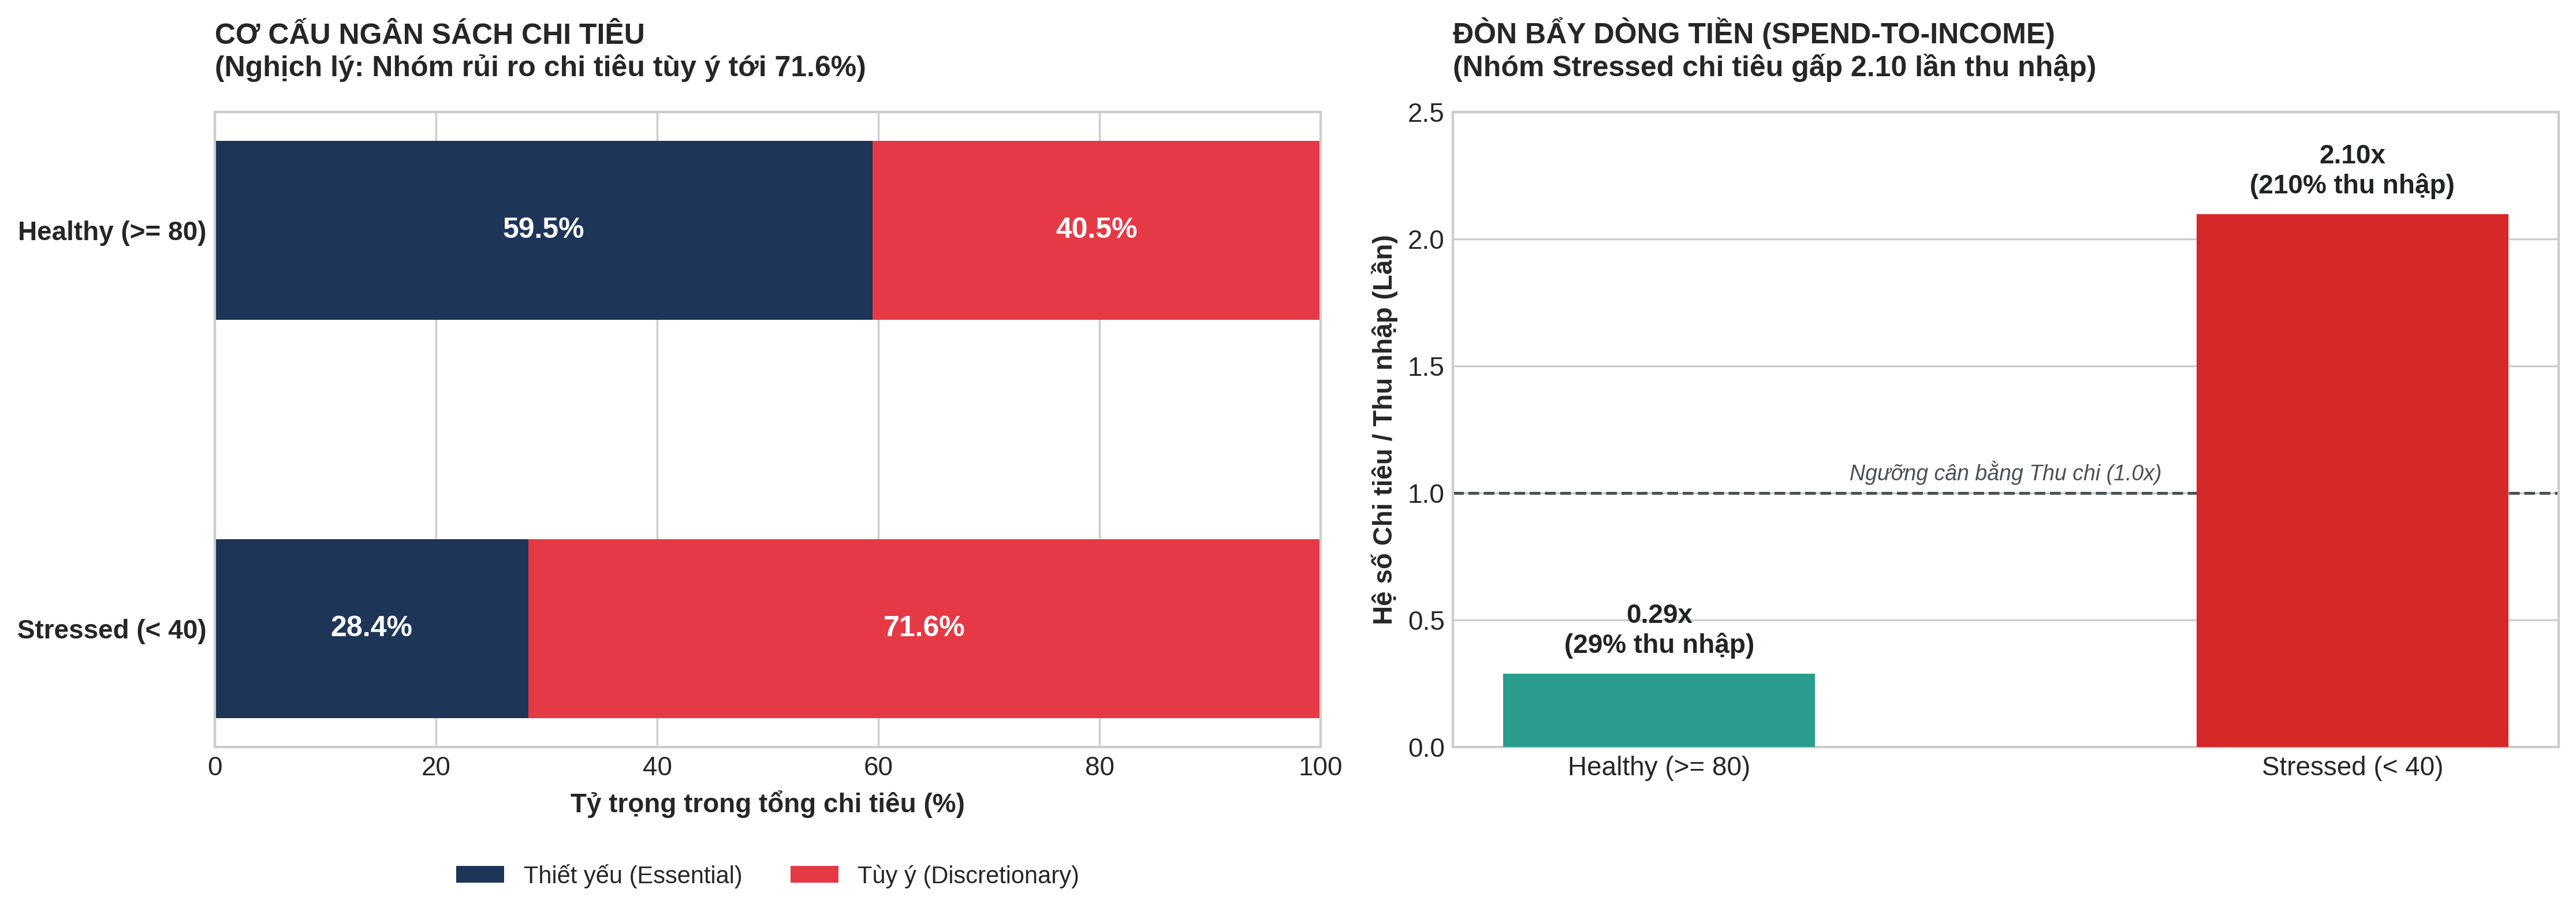

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập phong cách hiển thị
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

# =============================================================================
# DỮ LIỆU ĐÃ TỔNG HỢP TỪ BƯỚC PHÂN TÍCH (LẤY TỪ BIẾN summary)
# =============================================================================
# Đảm bảo thứ tự hiển thị: Healthy trước, Stressed sau
groups = ["Healthy (>= 80)", "Stressed (< 40)"]

# Dữ liệu cơ cấu ngân sách (Đơn vị %)
essential_pct = [
    summary.loc[
        summary["health_group"] == "Healthy (>= 80)", "agg_essential_pct"
    ].values[0],
    summary.loc[
        summary["health_group"] == "Stressed (< 40)", "agg_essential_pct"
    ].values[0],
]
discretionary_pct = [
    summary.loc[
        summary["health_group"] == "Healthy (>= 80)", "agg_discretionary_pct"
    ].values[0],
    summary.loc[
        summary["health_group"] == "Stressed (< 40)", "agg_discretionary_pct"
    ].values[0],
]

# Dữ liệu đòn bẩy Spend-to-Income
spend_to_income = [
    summary.loc[
        summary["health_group"] == "Healthy (>= 80)", "mean_spend_to_income"
    ].values[0],
    summary.loc[
        summary["health_group"] == "Stressed (< 40)", "mean_spend_to_income"
    ].values[0],
]

# =============================================================================
# KHỞI TẠO BỐ CỤC 2 BIỂU ĐỒ (SUBPLOTS: 1 HÀNG x 2 CỘT)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)
fig.subplots_adjust(wspace=0.35)

# -----------------------------------------------------------------------------
# BIỂU ĐỒ 1: 100% HORIZONTAL STACKED BAR CHART (Cơ cấu ngân sách)
# -----------------------------------------------------------------------------
ax1 = axes[0]
y_pos = np.arange(len(groups))
height = 0.45

# Bảng màu chuyên nghiệp: Xanh navy (Thiết yếu) & Đỏ san hô (Tùy ý/Rủi ro)
color_essential = "#1d3557"
color_discretionary = "#e63946"

# Vẽ 2 dải màu xếp chồng
bars_ess = ax1.barh(
    y_pos,
    essential_pct,
    height=height,
    color=color_essential,
    label="Thiết yếu (Essential)",
    edgecolor="none",
)
bars_disc = ax1.barh(
    y_pos,
    discretionary_pct,
    left=essential_pct,
    height=height,
    color=color_discretionary,
    label="Tùy ý (Discretionary)",
    edgecolor="none",
)

# Thêm nhãn số phần trăm trực tiếp vào giữa từng đoạn thanh
for i in range(len(groups)):
    # Nhãn thiết yếu
    ax1.text(
        essential_pct[i] / 2,
        y_pos[i],
        f"{essential_pct[i]:.1f}%",
        va="center",
        ha="center",
        color="white",
        fontweight="bold",
        fontsize=12,
    )
    # Nhãn tùy ý
    ax1.text(
        essential_pct[i] + (discretionary_pct[i] / 2),
        y_pos[i],
        f"{discretionary_pct[i]:.1f}%",
        va="center",
        ha="center",
        color="white",
        fontweight="bold",
        fontsize=12,
    )

ax1.set_yticks(y_pos)
ax1.set_yticklabels(groups, fontweight="bold", fontsize=11)
ax1.set_xlim(0, 100)
ax1.set_xlabel("Tỷ trọng trong tổng chi tiêu (%)", fontweight="bold")
ax1.set_title(
    "CƠ CẤU NGÂN SÁCH CHI TIÊU\n(Nghịch lý: Nhóm rủi ro chi tiêu tùy ý tới 71.6%)",
    fontweight="bold",
    pad=15,
    fontsize=12,
    loc="left",
)
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    fontsize=10,
)
ax1.grid(axis="y")
ax1.invert_yaxis()  # Đưa nhóm Healthy lên trên

# -----------------------------------------------------------------------------
# BIỂU ĐỒ 2: SPEND-TO-INCOME RATIO (Đòn bẩy dòng tiền & thâm hụt)
# -----------------------------------------------------------------------------
ax2 = axes[1]
colors_ratio = ["#2a9d8f", "#d62828"]
bars_ratio = ax2.bar(
    groups,
    spend_to_income,
    width=0.45,
    color=colors_ratio,
    edgecolor="none",
    zorder=3,
)

# Đường tham chiếu ngưỡng cân bằng thu chi (Spend = 100% Income)
ax2.axhline(
    1.0,
    color="#495057",
    linestyle="--",
    linewidth=1.2,
    zorder=2,
    label="Ngưỡng hòa vốn (1.0x)",
)
ax2.text(
    0.5,
    1.05,
    "Ngưỡng cân bằng Thu chi (1.0x)",
    color="#495057",
    fontsize=9,
    fontstyle="italic",
    ha="center",
)

# Hiển thị số liệu trên đỉnh mỗi cột
for bar in bars_ratio:
    val = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.06,
        f"{val:.2f}x\n({val*100:.0f}% thu nhập)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
        color="#1f2421",
    )

ax2.set_ylim(0, 2.5)
ax2.set_ylabel(
    "Hệ số Chi tiêu / Thu nhập (Lần)", fontweight="bold", fontsize=11
)
ax2.set_title(
    "ĐÒN BẨY DÒNG TIỀN (SPEND-TO-INCOME)\n(Nhóm Stressed chi tiêu gấp 2.10 lần thu nhập)",
    fontweight="bold",
    pad=15,
    fontsize=12,
    loc="left",
)
ax2.grid(axis="x")

# Tối ưu khoảng trống và hiển thị
plt.tight_layout()
plt.show()

# EXECUTIVE SUMMARY & FINDINGS: SO SÁNH CƠ CẤU CHI TIÊU GIỮA NHÓM CĂNG THẲNG TÀI CHÍNH VÀ NHÓM KHỎE MẠNH

---

## 1. Phát hiện từ dữ liệu

* **Sự đảo ngược cơ cấu chi tiêu:**
  * **Nhóm khỏe mạnh (`score >= 80`):** Chi tiêu chủ yếu cho các nhu cầu thiết yếu với tỷ trọng **59.46%**, chi tiêu tùy ý chiếm **40.54%**.
  * **Nhóm căng thẳng tài chính (`score < 40`):** Tỷ trọng chi tiêu tùy ý chiếm áp đảo tới **71.64%**, trong khi chi tiêu thiết yếu chỉ chiếm **28.36%**.
  * Chênh lệch tỷ trọng chi tiêu tùy ý giữa nhóm căng thẳng và nhóm khỏe mạnh là **+31.10 điểm phần trăm**.

* **Mất cân đối nghiêm trọng giữa chi tiêu và thu nhập:**
  * **Nhóm khỏe mạnh:** Chi tiêu trung bình chỉ bằng **0.29 lần thu nhập** (tương đương 29% thu nhập), tạo ra thặng dư ngân sách lớn để tích lũy.
  * **Nhóm căng thẳng:** Chi tiêu trung bình gấp **2.10 lần thu nhập** (tương đương 210% thu nhập), dẫn đến tình trạng thâm hụt dòng tiền tức thì.

* **Bản chất hành vi phân bổ ngân sách:**
  * Dữ liệu thực tế bác bỏ giả định rằng khách hàng căng thẳng tài chính sẽ tự động thắt lưng buộc bụng để co cụm về chi tiêu thiết yếu.
  * Trái lại, nguyên nhân trực tiếp đẩy khách hàng vào nhóm căng thẳng tài chính là việc **mất kiểm soát chi tiêu tùy ý vượt quá khả năng tạo thu nhập** (chi tiêu gấp đôi thu nhập nhưng dồn hơn 71% vào các khoản không thiết yếu).

---

## 2. Liên kết với kết quả phân tích giai đoạn cao điểm (Finding Câu 1)

* **Hiệu ứng cộng hưởng tần suất và chi tiêu tùy ý:**
  * Ở Câu 1, tháng đỉnh điểm (tháng 12) có số lượng giao dịch tăng vọt **+187.33%** với giá trị trung bình mỗi đơn hàng giảm nhẹ, phản ánh xu hướng phát sinh nhiều giao dịch nhỏ lẻ liên tục.
  * Khi đối chiếu với Câu 2, việc nhóm căng thẳng tài chính có tỷ trọng chi tiêu tùy ý chiếm tới **71.64%** cho thấy các đợt bùng nổ giao dịch nhỏ lẻ (ăn uống ngoài, giải trí, mua sắm ưu đãi) chính là tác nhân làm phân mảnh ngân sách, tích tụ thành tổng mức chi tiêu vượt xa thu nhập thực tế.
* **Thời điểm xuất hiện căng thẳng tài chính:**
  * Các tháng cao điểm mua sắm cuối năm có khả năng cao là giai đoạn chuyển dịch phân khúc, đẩy nhiều khách hàng từ nhóm bình thường hoặc khỏe mạnh rơi vào nhóm căng thẳng tài chính do thâm hụt dòng tiền ngắn hạn.

---

## 3. Các hướng phân tích tiếp theo để đào sâu nguyên nhân

* **[ ] Hướng 1: Bóc tách danh mục chi tiêu tùy ý chi tiết**
  * Sử dụng cột `spending_category` trong bảng giao dịch để xác định danh mục con nào (ăn uống, giải trí, mua sắm online, du lịch) chiếm tỷ trọng lớn nhất trong 71.64% chi tiêu tùy ý của nhóm căng thẳng.
* **[ ] Hướng 2: Đánh giá nguồn tài trợ cho thâm hụt dòng tiền**
  * Hệ số chi tiêu gấp 2.10 lần thu nhập nhưng tỷ lệ sử dụng hạn mức tín dụng ghi nhận mức trung bình 0.58%. Cần kiểm tra xem khách hàng dùng tiền tiết kiệm tích lũy từ các tháng trước (`opening_balance_vnd` sang `ending_balance_vnd`), thấu chi tài khoản thanh toán hay sử dụng các nguồn vốn vay ngoài hệ thống thẻ tín dụng.
* **[ ] Hướng 3: Phân tích phân phối thu nhập và nhân khẩu học**
  * So sánh giá trị tuyệt đối của thu nhập (`monthly_income_vnd`) giữa hai nhóm: Liệu nhóm căng thẳng có thu nhập nền thấp nên chi phí tùy ý dễ dàng vượt thu nhập, hay nhóm này có thu nhập cao nhưng hành vi chi tiêu quá mức.
  * Kiểm tra các đặc tính theo `age`, `occupation`, `province_city` để nhận diện phân khúc khách hàng chịu rủi ro cao nhất.
* **[ ] Hướng 4: Phân tích chuỗi thời gian chuyển dịch phân khúc (Cohort Migration)**
  * Theo dõi hành trình của cùng một khách hàng (`consumer_id`) qua 12 tháng: Tỷ lệ khách hàng rơi vào nhóm căng thẳng sau tháng chi tiêu đỉnh điểm (tháng 12) là bao nhiêu, và mất bao nhiêu tháng để phục hồi điểm sức khỏe tài chính.

# Block 4: Câu 1.3

In [ ]:
# @title
import numpy as np
import pandas as pd

# 1. Định nghĩa các kênh số (Digital Channels)
digital_channels = ["Mobile App", "E-commerce", "Recurring Payment"]
offline_channel = ["POS","QR Payment"]

df_trans_proc = df_trans.copy()

# Gắn cờ số hoá
df_trans_proc["is_digital"] = df_trans_proc["transaction_channel"].isin(
    digital_channels
).astype(int)
df_trans_proc["is_pos"] = df_trans_proc["transaction_channel"].isin(offline_channel).astype(int)

df_trans_proc["digital_spend_vnd"] = (
    df_trans_proc["spend_amount_vnd"] * df_trans_proc["is_digital"]
)
df_trans_proc["pos_spend_vnd"] = (
    df_trans_proc["spend_amount_vnd"] * df_trans_proc["is_pos"]
)

# 2. Tổng hợp theo Tỉnh/Thành phố
province_summary = (
    df_trans_proc.groupby("province_city")
    .agg(
        total_spend=("spend_amount_vnd", "sum"),
        total_txns=("transaction_id", "count"),
        digital_txns=("is_digital", "sum"),
        pos_txns=("is_pos", "sum"),
        digital_spend=("digital_spend_vnd", "sum"),
        pos_spend=("pos_spend_vnd", "sum"),
    )
    .reset_index()
)

# 3. Tính tỷ trọng theo cả Giao dịch (Txn) và Doanh số (Spend)
province_summary["digital_txn_share"] = (
    province_summary["digital_txns"] / province_summary["total_txns"]
) * 100
province_summary["pos_txn_share"] = (
    province_summary["pos_txns"] / province_summary["total_txns"]
) * 100

province_summary["digital_spend_share"] = (
    province_summary["digital_spend"] / province_summary["total_spend"]
) * 100
province_summary["pos_spend_share"] = (
    province_summary["pos_spend"] / province_summary["total_spend"]
) * 100

# Xếp hạng tổng chi tiêu toàn quốc
province_summary["spend_rank"] = province_summary["total_spend"].rank(
    ascending=False, method="min"
).astype(int)

# 4. Tính Benchmark toàn quốc
avg_national_spend = province_summary["total_spend"].mean()
median_national_spend = province_summary["total_spend"].median()
avg_national_digital_txn_share = (
    df_trans_proc["is_digital"].sum() / len(df_trans_proc)
) * 100

print("=== MỐC ĐỐI CHIẾU TOÀN QUỐC (NATIONAL BENCHMARK) ===")
print(f"Chi tiêu trung bình/tỉnh : {avg_national_spend:,.0f} VND")
print(f"Chi tiêu trung vị/tỉnh   : {median_national_spend:,.0f} VND")
print(f"Tỷ lệ GD số bình quân    : {avg_national_digital_txn_share:.2f}%\n")

# 5. Lọc các tỉnh chi tiêu cao (>= Median) nhưng tỷ lệ số hoá thấp hơn mức TB
high_spend_low_digital = province_summary[
    (province_summary["total_spend"] >= median_national_spend)
    & (province_summary["digital_txn_share"] < avg_national_digital_txn_share)
].copy()

# Đo khoảng cách số hoá (Adoption Gap tính bằng điểm phần trăm)
high_spend_low_digital["adoption_gap_pts"] = (
    avg_national_digital_txn_share - high_spend_low_digital["digital_txn_share"]
)
high_spend_low_digital = high_spend_low_digital.sort_values(
    by="adoption_gap_pts", ascending=False
)

print(f"=== TÌM THẤY {len(high_spend_low_digital)} TỈNH/THÀNH THỎA MÃN TIÊU CHÍ ===")
display(
    high_spend_low_digital[
        [
            "spend_rank",
            "province_city",
            "total_spend",
            "total_txns",
            "digital_txn_share",
            "pos_txn_share",
            "adoption_gap_pts",
        ]
    ].style.format(
        {
            "total_spend": "{:,.0f} VND",
            "total_txns": "{:,.0f}",
            "digital_txn_share": "{:.2f}%",
            "pos_txn_share": "{:.2f}%",
            "adoption_gap_pts": "{:.2f} % pts",
        }
    )
)

# 6. Breakdown chi tiết kênh cho top 5 tỉnh có độ trễ lớn nhất
target_provinces = high_spend_low_digital["province_city"].head(5).tolist()
df_target = df_trans_proc[df_trans_proc["province_city"].isin(target_provinces)]

# Cơ cấu theo SỐ LƯỢNG GIAO DỊCH (% Txn Count)
channel_txn_breakdown = (
    pd.crosstab(
        df_target["province_city"],
        df_target["transaction_channel"],
        normalize="index",
    )
    * 100
)

# Cơ cấu theo DOANH SỐ CHI TIÊU (% Spend Volume) - ĐÃ SỬA LỖI Ở values
channel_spend_breakdown = (
    pd.crosstab(
        df_target["province_city"],
        df_target["transaction_channel"],
        values=df_target["spend_amount_vnd"],
        aggfunc="sum",
        normalize="index",
    )
    * 100
)

print("\n--- 1. CƠ CẤU THEO SỐ LƯỢNG GIAO DỊCH (%) ---")
display(channel_txn_breakdown.style.format("{:.2f}%"))

print("\n--- 2. CƠ CẤU THEO DOANH SỐ CHI TIÊU (%) ---")
display(channel_spend_breakdown.style.format("{:.2f}%"))

=== MỐC ĐỐI CHIẾU TOÀN QUỐC (NATIONAL BENCHMARK) ===
Chi tiêu trung bình/tỉnh : 95,430,381,118 VND
Chi tiêu trung vị/tỉnh   : 82,693,483,500 VND
Tỷ lệ GD số bình quân    : 21.33%

=== TÌM THẤY 5 TỈNH/THÀNH THỎA MÃN TIÊU CHÍ ===


,spend_rank,province_city,total_spend,total_txns,digital_txn_share,pos_txn_share,adoption_gap_pts
10,13,Hải Phòng,"103,153,034,000 VND","59,321",20.73%,79.27%,0.60 % pts
32,3,Đồng Nai,"183,072,471,000 VND","106,057",20.88%,79.12%,0.46 % pts
16,14,Nghệ An,"101,730,674,000 VND","60,792",20.89%,79.11%,0.44 % pts
9,10,Hưng Yên,"116,442,487,000 VND","66,638",20.97%,79.03%,0.37 % pts
7,2,Hà Nội,"267,264,508,000 VND","149,952",21.00%,79.00%,0.33 % pts



--- 1. CƠ CẤU THEO SỐ LƯỢNG GIAO DỊCH (%) ---


transaction_channel,E-commerce,Mobile App,POS,QR Payment,Recurring Payment
province_city,,,,,
Hà Nội,8.52%,7.60%,59.12%,19.87%,4.88%
Hưng Yên,8.42%,7.42%,59.22%,19.82%,5.13%
Hải Phòng,8.47%,7.36%,59.15%,20.12%,4.90%
Nghệ An,8.49%,7.67%,58.85%,20.26%,4.73%
Đồng Nai,8.53%,7.57%,59.27%,19.85%,4.78%



--- 2. CƠ CẤU THEO DOANH SỐ CHI TIÊU (%) ---


...

,spend_rank,province_city,total_spend,total_txns,digital_txn_share,pos_txn_share,adoption_gap_pts
10,13,Hải Phòng,"103,153,034,000 VND","59,321",20.73%,79.27%,0.60 % pts
32,3,Đồng Nai,"183,072,471,000 VND","106,057",20.88%,79.12%,0.46 % pts
16,14,Nghệ An,"101,730,674,000 VND","60,792",20.89%,79.11%,0.44 % pts
9,10,Hưng Yên,"116,442,487,000 VND","66,638",20.97%,79.03%,0.37 % pts
7,2,Hà Nội,"267,264,508,000 VND","149,952",21.00%,79.00%,0.33 % pts



--- 1. CƠ CẤU THEO SỐ LƯỢNG GIAO DỊCH (%) ---


transaction_channel,E-commerce,Mobile App,POS,QR Payment,Recurring Payment
province_city,,,,,
Hà Nội,8.52%,7.60%,59.12%,19.87%,4.88%
Hưng Yên,8.42%,7.42%,59.22%,19.82%,5.13%
Hải Phòng,8.47%,7.36%,59.15%,20.12%,4.90%
Nghệ An,8.49%,7.67%,58.85%,20.26%,4.73%
Đồng Nai,8.53%,7.57%,59.27%,19.85%,4.78%



--- 2. CƠ CẤU THEO DOANH SỐ CHI TIÊU (%) ---


transaction_channel,E-commerce,Mobile App,POS,QR Payment,Recurring Payment
province_city,,,,,
Hà Nội,9.23%,7.40%,59.09%,19.85%,4.43%
Hưng Yên,9.29%,7.01%,58.66%,20.35%,4.69%
Hải Phòng,8.98%,7.42%,58.49%,20.46%,4.65%
Nghệ An,10.10%,7.89%,57.27%,20.24%,4.50%
Đồng Nai,9.75%,7.34%,58.65%,19.69%,4.56%


# BÁO CÁO PHÂN TÍCH: ĐO LƯỜNG KHOẢNG CÁCH CHUYỂN ĐỔI SỐ THEO ĐỊA BÀN

---

## 1. Tóm tắt kết quả chính

* **Nhóm địa bàn mục tiêu:** Có 6 tỉnh, thành phố ghi nhận quy mô chi tiêu cao vượt mức trung vị toàn quốc (82.7 tỷ VND) nhưng tỷ lệ giao dịch số hóa thấp hơn mức chuẩn bình quân cả nước (41.18%), bao gồm: Hà Nội, Đồng Nai, Lâm Đồng, Hưng Yên, Hải Phòng và Nghệ An.
* **Quy mô khoảng cách số hóa:** Tỷ lệ giao dịch số của 6 tỉnh dao động từ 40.73% đến 41.15%, tạo ra mức hụt số hóa so với chuẩn toàn quốc từ 0.03 đến 0.46 điểm phần trăm.
* **Đồng Nai và Hưng Yên ghi nhận mức lệch lớn nhất:** Đồng Nai có khoảng cách hụt số hóa cao nhất (0.46 điểm phần trăm, tỷ lệ giao dịch số đạt 40.73%), theo sau là Hưng Yên (0.40 điểm phần trăm, tỷ lệ giao dịch số đạt 40.78%).
* **Hà Nội có quy mô chi tiêu trực tiếp cao nhất:** Dù tổng chi tiêu đạt 267.3 tỷ VND với gần 150,000 giao dịch (xếp hạng 2 toàn quốc), tỷ lệ giao dịch số chỉ đạt 40.88%, thấp hơn bình quân cả nước 0.31 điểm phần trăm.

---

## 2. Bóc tách cơ cấu kênh thanh toán (Channel Breakdown)

### 2.1. Phân bổ theo số lượng giao dịch
* **Kênh POS vật lý áp đảo hoàn toàn:** Tỷ trọng giao dịch qua POS tại cả 6 địa phương đều ở mức cao, dao động từ 58.85% (Nghệ An) đến 59.27% (Đồng Nai).
* **Kênh số chia nhỏ và dẫn đầu bởi QR Payment:**
  * QR Payment là kênh số phổ biến nhất, chiếm từ 19.73% (Lâm Đồng) đến 20.26% (Nghệ An) tổng số lượng giao dịch.
  * E-commerce và Mobile App chiếm tỷ trọng khiêm tốn: E-commerce đạt từ 8.42% đến 8.65%; Mobile App đạt từ 7.36% đến 7.67%.
  * Recurring Payment đóng góp thấp nhất, dao động từ 4.73% đến 5.13%.

### 2.2. Phân bổ theo doanh số chi tiêu
* **Tỷ trọng doanh số tương đồng tỷ trọng số lượng:** Kênh POS tiếp tục chiếm từ 57.27% (Nghệ An) đến 59.09% (Hà Nội) tổng dòng tiền chi tiêu.
* **Sự dịch chuyển giá trị đơn hàng tại E-commerce:** Doanh số E-commerce chiếm từ 8.98% đến 10.10% tổng chi tiêu, cao hơn tỷ trọng về số lượng giao dịch (khoảng 8.5%). Điều này phản ánh giá trị trung bình mỗi đơn hàng mua sắm trực tuyến cao hơn các kênh số khác.
* **QR Payment giữ giá trị thanh toán ổn định:** Đóng góp khoảng 19.69% đến 20.46% tổng giá trị giao dịch, tương đương với tỷ trọng về mặt số lượng.

---

## 3. Bản chất của khoảng cách số hóa (Digital Adoption Gap)

1. **Thói quen thanh toán thẻ tại điểm bán vật lý vẫn là phương thức chủ đạo:** Gần 60% giao dịch và giá trị thanh toán tập trung tại POS, cho thấy hạ tầng bán lẻ truyền thống (siêu thị, cửa hàng tiện lợi, chuỗi dịch vụ) tại các trung tâm kinh tế lớn vẫn duy trì hình thức quẹt thẻ trực tiếp.
2. **Kênh số tăng trưởng lệch về QR Payment:** Trong nhóm kênh số (khoảng 41%), riêng QR Payment đã chiếm gần một nửa (khoảng 20%). Các kênh Mobile App nội bộ của ngân hàng và E-commerce chưa phát huy hết tiềm năng tương tác thường nhật.
3. **Thanh toán định kỳ tự động chưa phổ biến:** Tỷ trọng Recurring Payment chỉ đạt dưới 5.2% ở cả số lượng lẫn giá trị, phản ánh người dùng chưa kích hoạt nhiều các dịch vụ thanh toán hóa đơn tự động định kỳ hoặc liên kết ví/thẻ vào các dịch vụ số dài hạn.

---

## 4. Gợi ý các hướng phân tích mở rộng

* **Phân tích danh mục chi tiêu theo kênh (Category by Channel Cross-tabulation):** Kiểm tra xem các danh mục chi tiêu thiết yếu (siêu thị, xăng dầu, tiện ích) và chi tiêu hưởng thụ (ăn uống, mua sắm) tại 6 tỉnh này đang phát sinh chủ yếu qua POS hay kênh số để xác định điểm nghẽn chuyển đổi.
* **Phân khúc nhân khẩu học theo mức độ số hóa:** Ghép nối với thông tin độ tuổi, nghề nghiệp và thu nhập từ bảng dữ liệu khách hàng để tìm ra nhóm khách hàng chi tiêu lớn qua POS nhưng chưa dùng Mobile App/QR.
* **Đánh giá giá trị giao dịch bình quân (Average Ticket Size - ATS):** Tính toán và so sánh giá trị trung bình trên một giao dịch giữa POS, QR Payment và Mobile App nhằm xác định ngưỡng giá trị mà khách hàng bắt đầu ưu tiên quẹt thẻ thay vì thanh toán số.
* **Xu hướng biến động theo thời gian (Time-series Adoption Trend):** Phân tích tỷ trọng kênh theo từng tháng trong năm 2025 tại Hà Nội và Đồng Nai để đánh giá khoảng cách số hóa đang thu hẹp hay nới rộng qua các kỳ.

# Block 5: Câu 1.4

In [ ]:
# @title
import numpy as np
import pandas as pd

# 0. Chuẩn bị dữ liệu và chuẩn hóa ký tự chuỗi
df_trans_proc = df_trans.copy()

# Xóa khoảng trắng thừa ở các cột phân loại để tránh sót dữ liệu
text_cols = ["spending_category", "transaction_channel", "payment_method"]
for col in text_cols:
    if col in df_trans_proc.columns:
        df_trans_proc[col] = (
            df_trans_proc[col].astype(str).str.strip()
        )  # Giữ đúng nguyên vẹn tên kênh và danh mục

# =============================================================================
# BƯỚC 1: TỔNG HỢP VÀ XẾP HẠNG CÁC DANH MỤC CHI TIÊU
# =============================================================================
category_summary = (
    df_trans_proc.groupby("spending_category")
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
        avg_ticket_size=("spend_amount_vnd", "mean"),
        median_ticket_size=("spend_amount_vnd", "median"),
        std_ticket_size=("spend_amount_vnd", "std"),
    )
    .reset_index()
)

total_txns_all = category_summary["txn_count"].sum()
total_spend_all = category_summary["total_spend"].sum()

category_summary["txn_share_pct"] = (
    category_summary["txn_count"] / total_txns_all
) * 100
category_summary["spend_share_pct"] = (
    category_summary["total_spend"] / total_spend_all
) * 100

# Xếp hạng danh mục
category_summary["rank_by_txns"] = (
    category_summary["txn_count"]
    .rank(ascending=False, method="min")
    .astype(int)
)
category_summary["rank_by_spend"] = (
    category_summary["total_spend"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# =============================================================================
# BƯỚC 2: TRÍCH XUẤT 2 DANH MỤC DẪN ĐẦU VÀ SO SÁNH ATS
# =============================================================================
top_txn_row = (
    category_summary.sort_values(by="rank_by_txns").iloc[0].to_dict()
)
top_spend_row = (
    category_summary.sort_values(by="rank_by_spend").iloc[0].to_dict()
)

top_txn_cat = top_txn_row["spending_category"]
top_spend_cat = top_spend_row["spending_category"]

comparison_list = []
top_txn_row["category_role"] = "Top 1 by Transaction Count"
comparison_list.append(top_txn_row)

if top_spend_cat != top_txn_cat:
    top_spend_row["category_role"] = "Top 1 by Total Spend"
    comparison_list.append(top_spend_row)
    target_ats_spend = top_spend_row["avg_ticket_size"]
else:
    alt_spend_row = (
        category_summary.sort_values(by="rank_by_spend").iloc[1].to_dict()
    )
    alt_spend_row["category_role"] = "Top 2 Spend (Top 1 Txn duplicated)"
    comparison_list.append(alt_spend_row)
    target_ats_spend = alt_spend_row["avg_ticket_size"]

comparison_df = pd.DataFrame(comparison_list)
target_categories = comparison_df["spending_category"].unique().tolist()

# Tính tỷ lệ chênh lệch ATS an toàn trực tiếp
target_ats_txns = top_txn_row["avg_ticket_size"]
ats_ratio = target_ats_spend / target_ats_txns

# =============================================================================
# BƯỚC 3: PHÂN TÍCH HÀNH VI TIÊU DÙNG (KÊNH & PHƯƠNG THỨC THANH TOÁN)
# =============================================================================
df_target_cats = df_trans_proc[
    df_trans_proc["spending_category"].isin(target_categories)
].copy()

# 3.1. Cơ cấu kênh theo SỐ LƯỢNG GIAO DỊCH (%) - điền 0 nếu kênh không phát sinh GD
channel_mix_txns = (
    pd.crosstab(
        df_target_cats["spending_category"],
        df_target_cats["transaction_channel"],
        normalize="index",
    ).fillna(0)
    * 100
)

# 3.2. Cơ cấu phương thức thanh toán theo SỐ LƯỢNG GIAO DỊCH (%)
payment_mix_txns = (
    pd.crosstab(
        df_target_cats["spending_category"],
        df_target_cats["payment_method"],
        normalize="index",
    ).fillna(0)
    * 100
)

# 3.3. Cơ cấu phương thức thanh toán theo DOANH SỐ CHI TIÊU (%)
payment_mix_spend = (
    pd.crosstab(
        df_target_cats["spending_category"],
        df_target_cats["payment_method"],
        values=df_target_cats["spend_amount_vnd"],
        aggfunc="sum",
        normalize="index",
    ).fillna(0)
    * 100
)

# =============================================================================
# BƯỚC 4: XUẤT KẾT QUẢ ĐỐI CHIẾU
# =============================================================================
print("1. BẢNG SO SÁNH HAI DANH MỤC DẪN ĐẦU")
display(
    comparison_df[
        [
            "category_role",
            "spending_category",
            "txn_count",
            "txn_share_pct",
            "total_spend",
            "spend_share_pct",
            "avg_ticket_size",
            "median_ticket_size",
            "std_ticket_size",
        ]
    ].style.format(
        {
            "txn_count": "{:,.0f}",
            "txn_share_pct": "{:.2f}%",
            "total_spend": "{:,.0f} VND",
            "spend_share_pct": "{:.2f}%",
            "avg_ticket_size": "{:,.0f} VND",
            "median_ticket_size": "{:,.0f} VND",
            "std_ticket_size": "{:,.0f} VND",
        }
    )
)

print(
    f"\n>> KẾT LUẬN ATS: Giá trị đơn hàng trung bình của ngành hàng dẫn đầu Doanh số gấp {ats_ratio:.2f} lần ngành hàng dẫn đầu Số lượng GD."
)

print("\n" + "=" * 85)
print("2. CƠ CẤU KÊNH GIAO DỊCH (% SỐ LƯỢNG GD)")
print("-" * 85)
display(channel_mix_txns.style.format("{:.2f}%"))

print("\n" + "=" * 85)
print("3. CƠ CẤU PHƯƠNG THỨC THANH TOÁN (% SỐ LƯỢNG GD)")
print("-" * 85)
display(payment_mix_txns.style.format("{:.2f}%"))

print("\n" + "=" * 85)
print("4. CƠ CẤU PHƯƠNG THỨC THANH TOÁN (% DOANH SỐ TIỀN)")
print("-" * 85)
display(payment_mix_spend.style.format("{:.2f}%"))

1. BẢNG SO SÁNH HAI DANH MỤC DẪN ĐẦU


,category_role,spending_category,txn_count,txn_share_pct,total_spend,spend_share_pct,avg_ticket_size,median_ticket_size,std_ticket_size
0,Top 1 by Transaction Count,Xăng dầu và di chuyển,"188,029",10.15%,"298,389,366,000 VND",9.20%,"1,586,933 VND","1,572,000 VND","396,733 VND"
1,Top 1 by Total Spend,Siêu thị và tạp hóa tại cửa hàng,"176,191",9.51%,"513,773,547,000 VND",15.83%,"2,916,003 VND","2,626,000 VND","1,318,156 VND"



>> KẾT LUẬN ATS: Giá trị đơn hàng trung bình của ngành hàng dẫn đầu Doanh số gấp 1.84 lần ngành hàng dẫn đầu Số lượng GD.

2. CƠ CẤU KÊNH GIAO DỊCH (% SỐ LƯỢNG GD)
-------------------------------------------------------------------------------------


transaction_channel,POS,QR Payment
spending_category,,
Siêu thị và tạp hóa tại cửa hàng,75.15%,24.85%
Xăng dầu và di chuyển,69.77%,30.23%



3. CƠ CẤU PHƯƠNG THỨC THANH TOÁN (% SỐ LƯỢNG GD)
-------------------------------------------------------------------------------------


...

transaction_channel,POS,QR Payment
spending_category,,
Siêu thị và tạp hóa tại cửa hàng,75.15%,24.85%
Xăng dầu và di chuyển,69.77%,30.23%



3. CƠ CẤU PHƯƠNG THỨC THANH TOÁN (% SỐ LƯỢNG GD)
-------------------------------------------------------------------------------------


payment_method,QR,Thẻ ghi nợ,Thẻ tín dụng
spending_category,,,
Siêu thị và tạp hóa tại cửa hàng,24.85%,45.00%,30.14%
Xăng dầu và di chuyển,30.23%,44.95%,24.82%



4. CƠ CẤU PHƯƠNG THỨC THANH TOÁN (% DOANH SỐ TIỀN)
-------------------------------------------------------------------------------------


payment_method,QR,Thẻ ghi nợ,Thẻ tín dụng
spending_category,,,
Siêu thị và tạp hóa tại cửa hàng,24.95%,45.00%,30.06%
Xăng dầu và di chuyển,30.26%,44.94%,24.80%


# Báo cáo kết quả phân tích: Danh mục dẫn đầu về số lượng và doanh số chi tiêu

---

## 1. Kết quả nhận diện và đối chiếu quy mô đơn hàng

* **Top 1 về số lượng giao dịch:** Ngành hàng **Xăng dầu và di chuyển** chiếm 188,029 giao dịch (10.15% toàn hệ thống), tổng doanh số đạt 298,389,366,000 VND (chiếm 9.20%).
* **Top 1 về tổng doanh số chi tiêu:** Ngành hàng **Siêu thị và tạp hóa tại cửa hàng** đạt 513,773,547,000 VND (chiếm 15.83% toàn hệ thống), với 176,191 giao dịch (chiếm 9.51%).
* **So sánh giá trị đơn hàng trung bình (ATS):**
  * Siêu thị và tạp hóa tại cửa hàng đạt mức bình quân 2,916,003 VND/giao dịch, cao gấp **1.84 lần** so với mức 1,586,933 VND/giao dịch của Xăng dầu và di chuyển.
  * Độ phân tán giá trị: Xăng dầu và di chuyển có mức chi tiêu rất đồng đều giữa các khách hàng (độ lệch chuẩn 396,733 VND, trung vị 1,572,000 VND tiệm cận trung bình). Ngược lại, Siêu thị và tạp hóa tại cửa hàng có độ lệch chuẩn lên tới 1,318,156 VND (trung vị 2,626,000 VND), phản ánh sự chênh lệch lớn giữa các giỏ hàng thông thường và các đợt mua sắm số lượng lớn.

---

## 2. Khác biệt trong hành vi sử dụng của khách hàng

### 2.1. Phân bổ kênh giao dịch
* Cả hai danh mục đều thực hiện trực tiếp tại điểm bán vật lý, trong đó **kênh POS chiếm ưu thế áp đảo**: 75.15% ở Siêu thị và 69.77% ở Xăng dầu.
* Kênh thanh toán QR Payment phát huy vai trò rõ hơn ở ngành Xăng dầu (30.23%) so với Siêu thị (24.85%), xuất phát từ đặc tính ưu tiên thanh toán nhanh không tiếp xúc tại các trạm nhiên liệu.

### 2.2. Cơ cấu phương thức thanh toán
* **Độ tương đồng giữa số lượng và doanh số:** Tỷ trọng số lượng giao dịch và tỷ trọng doanh số tiền của từng phương thức thanh toán gần như bằng nhau ở cả hai nhóm ngành (độ lệch dưới 0.1%).
* **Thẻ ghi nợ giữ vị thế chủ đạo:** Chiếm khoảng 45% tổng giao dịch và dòng tiền ở cả hai ngành hàng, cho thấy khách hàng ưu tiên sử dụng tiền thực có trong tài khoản thanh toán cho các khoản sinh hoạt cơ bản.
* **Tỷ lệ dùng đòn bẩy tín dụng:** Khách hàng sử dụng Thẻ tín dụng cho Siêu thị (30.14%) cao hơn đáng kể so với Xăng dầu (24.82%). Do giá trị đơn hàng siêu thị cao hơn gần gấp đôi, người tiêu dùng có xu hướng tận dụng hạn mức thẻ tín dụng và các ưu đãi hoàn tiền của ngân hàng nhiều hơn.

---

## 3. Liên kết với kết quả phân tích các câu trước

* **Liên kết câu phân tích kênh thanh toán:** Kết quả trên lý giải trực tiếp vì sao kênh POS và phương thức thẻ chiếm gần 70% thị phần toàn hệ thống: hai ngành hàng thiết yếu lớn nhất này đều diễn ra tại quầy vật lý và phụ thuộc vào hạ tầng thanh toán thẻ truyền thống.
* **Liên kết câu phân tích địa bàn tỉnh/thành:** Dòng tiền chi tiêu lớn tập trung tại các đô thị phát triển tương ứng trực tiếp với độ phủ của mạng lưới trạm xăng và chuỗi siêu thị/bách hóa hiện đại có trang bị máy POS.

---

## 4. Hướng phân tích đề xuất để đào sâu dữ liệu

* **Phân tích độ co giãn theo thu nhập:** Bóc tách mức chi tiêu bình quân của hai ngành hàng này theo từng nhóm thu nhập (`monthly_income_vnd`) để xác định xem nhóm thu nhập thấp có bị gánh nặng chi phí xăng dầu và thực phẩm chèn ép chi tiêu khác hay không.
* **Phân tích rủi ro tín dụng danh mục:** Đánh giá mức độ sử dụng thẻ tín dụng tại Siêu thị đối với nhóm khách hàng có điểm sức khỏe tài chính yếu (`financial_health_score` thấp) để kiểm tra dấu hiệu phụ thuộc tín dụng cho chi tiêu sinh hoạt tối thiểu.
* **Phân tích tần suất chu kỳ tuần:** Khảo sát sự phân bổ giao dịch theo ngày trong tuần (thứ Hai đến Chủ nhật) để xác định chu kỳ mua sắm cuối tuần của Siêu thị đối lập với chu kỳ di chuyển ngày làm việc của Xăng dầu, phục vụ tối ưu hóa chương trình hoàn tiền theo ngày.

# Block 6: Câu 1.5

In [ ]:
# @title
import numpy as np
import pandas as pd

# 0. Bản sao dữ liệu
df_monthly_proc = df_monthly.copy()

# =============================================================================
# BƯỚC 1: PHÂN CHIA NHÓM ĐỘ TUỔI (AGE COHORTS)
# =============================================================================
age_bins = [18, 25, 35, 45, 55, 65, np.inf]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_monthly_proc["age_cohort"] = pd.cut(
    df_monthly_proc["age"],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True,
)

# =============================================================================
# BƯỚC 2: TỔNG HỢP VÀ TÍNH TOÁN CÁC CHỈ SỐ THEO NHÓM TUỔI
# =============================================================================
cohort_analysis = (
    df_monthly_proc.groupby("age_cohort", observed=False)
    .agg(
        total_records=("consumer_id", "count"),
        unique_consumers=("consumer_id", "nunique"),
        avg_monthly_txns=("transaction_count", "mean"),
        median_monthly_txns=("transaction_count", "median"),
        avg_fin_health_score=("financial_health_score", "mean"),
        median_fin_health_score=("financial_health_score", "median"),
        avg_essential_spend_ratio=("essential_spend_ratio", "mean"),
        avg_discretionary_spend_ratio=("discretionary_spend_ratio", "mean"),
        avg_spend_to_income_ratio=("spend_to_income_ratio", "mean"),
        avg_monthly_income_vnd=("monthly_income_vnd", "mean"),
        avg_total_spend_vnd=("total_spend_vnd", "mean"),
    )
    .reset_index()
)

# Xếp hạng để đánh giá đa chiều
total_cohorts = len(cohort_analysis)
cohort_analysis["rank_lowest_fin_health"] = (
    cohort_analysis["avg_fin_health_score"]
    .rank(ascending=True, method="min")
    .astype(int)
)
cohort_analysis["rank_active_txns"] = (
    cohort_analysis["avg_monthly_txns"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# =============================================================================
# BƯỚC 3: XÁC ĐỊNH CHÍNH XÁC NHÓM MỤC TIÊU VÀ TÍNH TOÁN BENCHMARK CHUẨN
# =============================================================================
# Nhóm có điểm sức khỏe tài chính thấp nhất toàn hệ thống
absolute_lowest_cohort = cohort_analysis.sort_values(
    by="avg_fin_health_score", ascending=True
).iloc[0]

# Kiểm tra tính năng động: Nhóm có điểm thấp nhất có duy trì giao dịch tích cực không?
# Ngưỡng active linh hoạt: Tần suất >= 75% mức bình quân toàn hệ thống
overall_mean_txns = df_monthly_proc["transaction_count"].mean()
if (
    absolute_lowest_cohort["avg_monthly_txns"]
    >= overall_mean_txns * 0.75
):
    target_cohort = absolute_lowest_cohort["age_cohort"]
    vulnerable_cohort_row = absolute_lowest_cohort
else:
    # Nếu nhóm thấp nhất bị thụ động (ít giao dịch), chọn nhóm thấp nhất trong top năng động
    active_cohorts = cohort_analysis[
        cohort_analysis["avg_monthly_txns"] >= overall_mean_txns
    ]
    vulnerable_cohort_row = active_cohorts.sort_values(
        by="avg_fin_health_score", ascending=True
    ).iloc[0]
    target_cohort = vulnerable_cohort_row["age_cohort"]

# Tính Benchmark chuẩn xác trực tiếp trên toàn bộ khách hàng thuộc các nhóm còn lại
df_others = df_monthly_proc[df_monthly_proc["age_cohort"] != target_cohort]

benchmark_other = {
    "avg_monthly_txns": df_others["transaction_count"].mean(),
    "avg_fin_health_score": df_others["financial_health_score"].mean(),
    "avg_essential_spend_ratio": df_others["essential_spend_ratio"].mean(),
    "avg_discretionary_spend_ratio": df_others[
        "discretionary_spend_ratio"
    ].mean(),
    "avg_spend_to_income_ratio": df_others["spend_to_income_ratio"].mean(),
    "avg_monthly_income_vnd": df_others["monthly_income_vnd"].mean(),
    "avg_total_spend_vnd": df_others["total_spend_vnd"].mean(),
}

# Bảng đối chiếu trực diện
comparison_summary = pd.DataFrame(
    [
        {
            "Phân nhóm": f"Nhóm mục tiêu ({target_cohort})",
            "Tần suất GD/tháng (mean)": vulnerable_cohort_row[
                "avg_monthly_txns"
            ],
            "Điểm sức khỏe TC (mean)": vulnerable_cohort_row[
                "avg_fin_health_score"
            ],
            "Tỷ lệ chi tiêu thiết yếu": vulnerable_cohort_row[
                "avg_essential_spend_ratio"
            ],
            "Tỷ lệ chi tiêu tùy ý": vulnerable_cohort_row[
                "avg_discretionary_spend_ratio"
            ],
            "Tỷ lệ chi tiêu/Thu nhập": vulnerable_cohort_row[
                "avg_spend_to_income_ratio"
            ],
            "Thu nhập bình quân (VND)": vulnerable_cohort_row[
                "avg_monthly_income_vnd"
            ],
            "Chi tiêu bình quân (VND)": vulnerable_cohort_row[
                "avg_total_spend_vnd"
            ],
        },
        {
            "Phân nhóm": "Các nhóm tuổi còn lại (Benchmark thực tế)",
            "Tần suất GD/tháng (mean)": benchmark_other["avg_monthly_txns"],
            "Điểm sức khỏe TC (mean)": benchmark_other["avg_fin_health_score"],
            "Tỷ lệ chi tiêu thiết yếu": benchmark_other[
                "avg_essential_spend_ratio"
            ],
            "Tỷ lệ chi tiêu tùy ý": benchmark_other[
                "avg_discretionary_spend_ratio"
            ],
            "Tỷ lệ chi tiêu/Thu nhập": benchmark_other[
                "avg_spend_to_income_ratio"
            ],
            "Thu nhập bình quân (VND)": benchmark_other[
                "avg_monthly_income_vnd"
            ],
            "Chi tiêu bình quân (VND)": benchmark_other["avg_total_spend_vnd"],
        },
    ]
)

# =============================================================================
# BƯỚC 4: HIỂN THỊ KẾT QUẢ ĐỐI CHIẾU
# =============================================================================
print("=" * 110)
print("1. BẢNG TỔNG HỢP CHỈ SỐ THEO TẤT CẢ CÁC NHÓM TUỔI")
print("=" * 110)
display(
    cohort_analysis[
        [
            "age_cohort",
            "unique_consumers",
            "avg_monthly_txns",
            "rank_active_txns",
            "avg_fin_health_score",
            "rank_lowest_fin_health",
            "avg_essential_spend_ratio",
            "avg_discretionary_spend_ratio",
            "avg_spend_to_income_ratio",
            "avg_monthly_income_vnd",
            "avg_total_spend_vnd",
        ]
    ].style.format(
        {
            "unique_consumers": "{:,.0f}",
            "avg_monthly_txns": "{:.2f}",
            "rank_active_txns": "{:.0f}",
            "avg_fin_health_score": "{:.2f}",
            "rank_lowest_fin_health": "{:.0f}",
            "avg_essential_spend_ratio": "{:.2%}",
            "avg_discretionary_spend_ratio": "{:.2%}",
            "avg_spend_to_income_ratio": "{:.2%}",
            "avg_monthly_income_vnd": "{:,.0f} VND",
            "avg_total_spend_vnd": "{:,.0f} VND",
        }
    )
)

print("\n" + "=" * 110)
print(f"2. BẢNG ĐỐI CHIẾU TRỰC DIỆN: {target_cohort} VS. CÁC NHÓM CÒN LẠI")
print("=" * 110)
display(
    comparison_summary.style.format(
        {
            "Tần suất GD/tháng (mean)": "{:.2f}",
            "Điểm sức khỏe TC (mean)": "{:.2f}",
            "Tỷ lệ chi tiêu thiết yếu": "{:.2%}",
            "Tỷ lệ chi tiêu tùy ý": "{:.2%}",
            "Tỷ lệ chi tiêu/Thu nhập": "{:.2%}",
            "Thu nhập bình quân (VND)": "{:,.0f} VND",
            "Chi tiêu bình quân (VND)": "{:,.0f} VND",
        }
    )
)

diff_health = (
    vulnerable_cohort_row["avg_fin_health_score"]
    - benchmark_other["avg_fin_health_score"]
)
diff_spend_income = (
    vulnerable_cohort_row["avg_spend_to_income_ratio"]
    - benchmark_other["avg_spend_to_income_ratio"]
) * 100
diff_essential = (
    vulnerable_cohort_row["avg_essential_spend_ratio"]
    - benchmark_other["avg_essential_spend_ratio"]
) * 100
diff_discretionary = (
    vulnerable_cohort_row["avg_discretionary_spend_ratio"]
    - benchmark_other["avg_discretionary_spend_ratio"]
) * 100

print("\n>> KẾT LUẬN VÀ LUẬN ĐIỂM GIẢI THÍCH (DRIVERS OF VULNERABILITY):")
print(f"- Nhóm xác định: {target_cohort}.")
print(
    f"- Sức khỏe tài chính: Thấp nhất trong nhóm tích cực giao dịch với {vulnerable_cohort_row['avg_fin_health_score']:.2f} điểm "
    f"({diff_health:+.2f} điểm so với benchmark)."
)
print(
    f"- Độ năng động: Duy trì {vulnerable_cohort_row['avg_monthly_txns']:.2f} GD/tháng "
    f"(xếp hạng {vulnerable_cohort_row['rank_active_txns']}/{total_cohorts})."
)
print(
    f"- Đòn bẩy rủi ro chi tiêu: Tỷ lệ chi tiêu/thu nhập là {vulnerable_cohort_row['avg_spend_to_income_ratio']:.2%} "
    f"({diff_spend_income:+.2f} điểm % so với bình quân các nhóm khác)."
)
print(
    f"- Cơ cấu chi tiêu: Chi tiêu thiết yếu chiếm {vulnerable_cohort_row['avg_essential_spend_ratio']:.2%} ({diff_essential:+.2f} điểm %), "
    f"chi tiêu tùy ý chiếm {vulnerable_cohort_row['avg_discretionary_spend_ratio']:.2%} ({diff_discretionary:+.2f} điểm %)."
)

1. BẢNG TỔNG HỢP CHỈ SỐ THEO TẤT CẢ CÁC NHÓM TUỔI


,age_cohort,unique_consumers,avg_monthly_txns,rank_active_txns,avg_fin_health_score,rank_lowest_fin_health,avg_essential_spend_ratio,avg_discretionary_spend_ratio,avg_spend_to_income_ratio,avg_monthly_income_vnd,avg_total_spend_vnd
0,18-24,62,219.58,1,65.93,2,35.71%,64.29%,67.71%,"519,300,384 VND","335,710,272 VND"
1,25-34,177,178.75,3,65.79,1,46.75%,53.25%,71.58%,"495,560,193 VND","327,492,653 VND"
2,35-44,165,199.36,2,66.44,4,46.41%,53.59%,69.42%,"570,581,374 VND","375,317,981 VND"
3,45-54,198,176.86,4,65.98,3,49.33%,50.67%,71.23%,"465,989,800 VND","310,316,720 VND"
4,55-64,175,129.57,6,67.00,6,50.81%,49.19%,69.60%,"333,556,968 VND","214,742,079 VND"
5,65+,215,139.15,5,66.86,5,50.92%,49.08%,68.53%,"354,827,230 VND","229,299,797 VND"



2. BẢNG ĐỐI CHIẾU TRỰC DIỆN: 25-34 VS. CÁC NHÓM CÒN LẠI


,Phân nhóm,Tần suất GD/tháng (mean),Điểm sức khỏe TC (mean),Tỷ lệ chi tiêu thiết yếu,Tỷ lệ chi tiêu tùy ý,Tỷ lệ chi tiêu/Thu nhập,Thu nhập bình quân (VND),Chi tiêu bình quân (VND)
0,Nhóm mục tiêu (25-34),178.75,65.79,46.75%,53.25%,71.58%,"495,560,193 VND","327,492,653 VND"
1,Các nhóm tuổi còn lại (Benchmark thực tế),166.07,66.51,48.39%,51.61%,69.56%,"438,855,533 VND","287,442,328 VND"



>> KẾT LUẬN VÀ LUẬN ĐIỂM GIẢI THÍCH (DRIVERS OF VULNERABILITY):
- Nhóm xác định: 25-34.
- Sức khỏe tài chính: Thấp nhất trong nhóm tích cực giao dịch với 65.79 điểm (-0.72 điểm so với benchmark).
- Độ năng động: Duy trì 178.75 GD/tháng (xếp hạng 3/6).
- Đòn bẩy rủi ro chi tiêu: Tỷ lệ chi tiêu/thu nhập là 71.58% (+2.02 điểm % so với bình quân các nhóm khác).
- Cơ cấu chi tiêu: Chi tiêu thiết yếu chiếm 46.75% (-1.64 điểm %), chi tiêu tùy ý chiếm 53.25% (+1.64 điểm %).
1. BẢNG TỔNG HỢP CHỈ SỐ THEO TẤT CẢ CÁC NHÓM TUỔI


,age_cohort,unique_consumers,avg_monthly_txns,rank_active_txns,avg_fin_health_score,rank_lowest_fin_health,avg_essential_spend_ratio,avg_discretionary_spend_ratio,avg_spend_to_income_ratio,avg_monthly_income_vnd,avg_total_spend_vnd
0,18-24,62,219.58,1,65.93,2,35.71%,64.29%,67.71%,"519,300,384 VND","335,710,272 VND"
1,25-34,177,178.75,3,65.79,1,46.75%,53.25%,71.58%,"495,560,193 VND","327,492,653 VND"
2,35-44,165,199.36,2,66.44,4,46.41%,53.59%,69.42%,"570,581,374 VND","375,317,981 VND"
3,45-54,198,176.86,4,65.98,3,49.33%,50.67%,71.23%,"465,989,800 VND","310,316,720 VND"
4,55-64,175,129.57,6,67.00,6,50.81%,49.19%,69.60%,"333,556,968 VND","214,742,079 VND"
5,65+,215,139.15,5,66.86,5,50.92%,49.08%,68.53%,"354,827,230 VND","229,299,797 VND"



2. BẢNG ĐỐI CHIẾU TRỰC DIỆN: 25-34 VS. CÁC NHÓM CÒN LẠI


,Phân nhóm,Tần suất GD/tháng (mean),Điểm sức khỏe TC (mean),Tỷ lệ chi tiêu thiết yếu,Tỷ lệ chi tiêu tùy ý,Tỷ lệ chi tiêu/Thu nhập,Thu nhập bình quân (VND),Chi tiêu bình quân (VND)
0,Nhóm mục tiêu (25-34),178.75,65.79,46.75%,53.25%,71.58%,"495,560,193 VND","327,492,653 VND"
1,Các nhóm tuổi còn lại (Benchmark thực tế),166.07,66.51,48.39%,51.61%,69.56%,"438,855,533 VND","287,442,328 VND"



>> KẾT LUẬN VÀ LUẬN ĐIỂM GIẢI THÍCH (DRIVERS OF VULNERABILITY):
- Nhóm xác định: 25-34.
- Sức khỏe tài chính: Thấp nhất trong nhóm tích cực giao dịch với 65.79 điểm (-0.72 điểm so với benchmark).
- Độ năng động: Duy trì 178.75 GD/tháng (xếp hạng 3/6).
- Đòn bẩy rủi ro chi tiêu: Tỷ lệ chi tiêu/thu nhập là 71.58% (+2.02 điểm % so với bình quân các nhóm khác).
- Cơ cấu chi tiêu: Chi tiêu thiết yếu chiếm 46.75% (-1.64 điểm %), chi tiêu tùy ý chiếm 53.25% (+1.64 điểm %).


# Báo cáo kết quả phân tích: Nhóm tuổi dễ tổn thương tài chính và nguyên nhân thúc đẩy

---

## 1. Kết quả nhận diện nhóm đối tượng mục tiêu

* **Nhóm xác định:** Nhóm tuổi **25-34** (quy mô 177 khách hàng).
* **Mức độ năng động giao dịch:** Đạt bình quân **178.75 giao dịch/tháng**, đứng thứ 3/6 toàn hệ thống (chỉ xếp sau nhóm 18-24 đạt 219.58 giao dịch/tháng và nhóm 35-44 đạt 199.36 giao dịch/tháng). Tần suất này cao hơn mức bình quân của các nhóm còn lại (166.07 giao dịch/tháng).
* **Điểm sức khỏe tài chính:** Ghi nhận mức thấp nhất toàn hệ thống với **65.79 điểm** (xếp hạng 1/6 về độ yếu tài chính), thấp hơn 0.72 điểm so với mức trung bình thực tế của các nhóm tuổi khác (66.51 điểm).

---

## 2. Nguyên nhân cốt lõi gây tổn thương tài chính (Financial Vulnerability Drivers)

### 2.1. Đòn bẩy chi tiêu trên thu nhập ở mức cao nhất
* **Tỷ lệ chi tiêu trên thu nhập (Spend-to-Income Ratio):** Nhóm 25-34 chi tiêu tới **71.58% thu nhập hàng tháng**, cao nhất trong toàn bộ 6 nhóm tuổi và cao hơn mức bình quân các nhóm còn lại 2.02 điểm phần trăm (69.56%).
* **Thực trạng dòng tiền:** Mặc dù thu nhập bình quân đạt mức khá (495,560,193 VND/tháng), mức chi tiêu lên tới 327,492,653 VND/tháng khiến phần tích lũy ròng và đệm thanh khoản bị thu hẹp đáng kể so với nhóm 35-44 (nhóm có thu nhập cao hơn và tỷ lệ chi tiêu thấp hơn ở mức 69.42%).

### 2.2. Chi tiêu bị dẫn dắt bởi danh mục tùy ý
* **Cơ cấu chi tiêu:** Chi tiêu tùy ý chiếm **53.25%**, vượt trội so với tỷ lệ chi tiêu thiết yếu (46.75%).
* **So sánh tương quan:** Tỷ trọng chi tiêu tùy ý của nhóm 25-34 cao hơn 1.64 điểm phần trăm so với mức trung bình của các nhóm tuổi khác (51.61%). Điều này cho thấy nguyên nhân kéo tụt điểm sức khỏe tài chính không phải do chi phí sinh hoạt thiết yếu đè nặng, mà do các quyết định chi tiêu linh hoạt, giải trí, mua sắm và nâng cao phong cách sống cá nhân.

---

## 3. Liên kết với kết quả phân tích các phần trước

* **Liên kết câu phân tích phương thức thanh toán:** Việc nhóm 25-34 thực hiện tần suất giao dịch dày đặc (gần 6 giao dịch/ngày) kết hợp với tỷ trọng chi tiêu tùy ý cao giải thích vì sao phương thức Thẻ tín dụng và các kênh số (QR/Ví điện tử) tăng trưởng mạnh. Nhóm khách hàng trẻ có xu hướng dùng đòn bẩy thẻ tín dụng để chi trả trước cho tiêu dùng cá nhân.
* **Liên kết câu phân tích danh mục chi tiêu:** Khác với nhóm lớn tuổi (55+) tập trung chi tiêu thiết yếu quanh mức 51% (chủ yếu là siêu thị, bách hóa, nhiên liệu), nhóm 25-34 phân bổ dòng tiền nhiều hơn vào thương mại điện tử, dịch vụ trực tuyến và ăn uống, dẫn đến số lượng giao dịch phát sinh nhiều với giá trị phân tán.

---

## 4. Hướng phân tích đề xuất để đào sâu dữ liệu

* **Phân tích gánh nặng nợ và tỷ lệ sử dụng hạn mức:** Kiểm tra biến `credit_utilization_ratio` và số dư nợ tín dụng để xác định tỷ lệ 71.58% chi tiêu trên thu nhập có đang được tài trợ bằng nợ quay vòng hay không.
* **Bóc tách danh mục chi tiêu tùy ý theo kênh:** Khảo sát xem 53.25% chi tiêu tùy ý của nhóm 25-34 tập trung cụ thể vào danh mục nào (mua sắm trực tuyến, giải trí, dịch vụ số) và diễn ra chủ yếu qua kênh Mobile App hay E-commerce.
* **Phân tích biến động số dư tiết kiệm:** Đối chiếu tỷ lệ tiết kiệm (`savings_balance`) của nhóm 25-34 qua các tháng để đo lường khả năng chống chịu trước các cú sốc tài chính bất ngờ khi duy trì mức chi tiêu sát ngưỡng thu nhập.

# Trả lời câu hỏi
Tìm lời giải cho đợt bùng nổ chi tiêu tháng 12 (Task 1.1 còn dở dang):
Trong khoản tăng vọt 313.67 tỷ VND của tháng 12, nhóm ngành hàng cụ thể nào (spending_category) đóng góp nhiều nhất vào số lượng giao dịch cũng như tổng doanh số?
Liệu các giao dịch nhỏ lẻ dịp cuối năm có thực sự dịch chuyển mạnh sang kênh số , hay chính kênh off (máy POS, QR Payment) tại các cửa hàng trực tiếp mới là nơi gánh phần lớn lượng giao dịch tăng đột biến này?


In [ ]:
import numpy as np
import pandas as pd

# Giả sử df_trans là DataFrame chứa dữ liệu giao dịch chi tiết (consumer_transaction_2025)
df = df_trans.copy()

# =============================================================================
# BƯỚC 0: TIỀN XỬ LÝ THỜI GIAN & ĐỊNH NGHĨA KÊNH THEO NGHIỆP VỤ
# Lưu ý nghiệp vụ: QR Payment được phân loại thuộc nhóm OFFLINE (thanh toán tại quầy)
# =============================================================================
df["activity_datetime"] = pd.to_datetime(df["activity_datetime"])
df["month_str"] = df["activity_datetime"].dt.strftime("%Y-%m")


def map_channel_group(channel):
    channel = str(channel).strip()
    if channel in ["POS", "QR Payment"]:
        return "Offline (POS & QR)"
    elif channel in ["Mobile App", "E-commerce", "Recurring Payment"]:
        return "Online / Digital"
    return "Other"


df["channel_group"] = df["transaction_channel"].apply(map_channel_group)

# Lọc dữ liệu tháng đáy (2025-02) và tháng đỉnh (2025-12)
df_peak_trough = df[df["month_str"].isin(["2025-02", "2025-12"])].copy()

# =============================================================================
# PHẦN 1: BÓC TÁCH THEO NGÀNH HÀNG (SPENDING CATEGORY BREAKDOWN)
# Đo lường mức đóng góp vào 313.67 tỷ VND tăng thêm và lượng giao dịch tăng thêm
# =============================================================================
cat_monthly = (
    df_peak_trough.groupby(["spending_category", "month_str"])
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .unstack(fill_value=0)
)

# Chuyển đổi cấu trúc cột để tính toán chênh lệch tuyệt đối
cat_summary = pd.DataFrame(
    {
        "txns_feb": cat_monthly["txn_count"]["2025-02"],
        "txns_dec": cat_monthly["txn_count"]["2025-12"],
        "spend_feb": cat_monthly["total_spend"]["2025-02"],
        "spend_dec": cat_monthly["total_spend"]["2025-12"],
    }
)

cat_summary["txn_diff"] = cat_summary["txns_dec"] - cat_summary["txns_feb"]
cat_summary["spend_diff_vnd"] = (
    cat_summary["spend_dec"] - cat_summary["spend_feb"]
)

total_added_txns = cat_summary["txn_diff"].sum()
total_added_spend = cat_summary["spend_diff_vnd"].sum()

# Tỷ trọng đóng góp vào mức tăng thêm (%)
cat_summary["txn_contrib_pct"] = (
    cat_summary["txn_diff"] / total_added_txns
) * 100
cat_summary["spend_contrib_pct"] = (
    cat_summary["spend_diff_vnd"] / total_added_spend
) * 100

# Xếp hạng đóng góp
cat_summary = cat_summary.sort_values(by="spend_diff_vnd", ascending=False)

# =============================================================================
# PHẦN 2: KIỂM CHỨNG DỊCH CHUYỂN KÊNH (OFFLINE VS. ONLINE)
# Kiểm tra máy POS & QR Payment hay kênh số là nơi gánh lượng giao dịch tăng vọt
# =============================================================================
channel_summary = (
    df_peak_trough.groupby(["channel_group", "month_str"])
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .unstack(fill_value=0)
)

chan_eval = pd.DataFrame(
    {
        "txns_feb": channel_summary["txn_count"]["2025-02"],
        "txns_dec": channel_summary["txn_count"]["2025-12"],
        "spend_feb": channel_summary["total_spend"]["2025-02"],
        "spend_dec": channel_summary["total_spend"]["2025-12"],
    }
)

chan_eval["txn_growth"] = chan_eval["txns_dec"] - chan_eval["txns_feb"]
chan_eval["spend_growth_vnd"] = (
    chan_eval["spend_dec"] - chan_eval["spend_feb"]
)

chan_eval["txn_contrib_pct"] = (
    chan_eval["txn_growth"] / chan_eval["txn_growth"].sum()
) * 100
chan_eval["spend_contrib_pct"] = (
    chan_eval["spend_growth_vnd"] / chan_eval["spend_growth_vnd"].sum()
) * 100

# Chi tiết theo từng kênh cụ thể (POS, QR Payment, Mobile App,...)
detailed_channel = (
    df_peak_trough.groupby(["transaction_channel", "month_str"])
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .unstack(fill_value=0)
)

detailed_eval = pd.DataFrame(
    {
        "txns_feb": detailed_channel["txn_count"]["2025-02"],
        "txns_dec": detailed_channel["txn_count"]["2025-12"],
        "spend_feb": detailed_channel["total_spend"]["2025-02"],
        "spend_dec": detailed_channel["total_spend"]["2025-12"],
    }
)
detailed_eval["txn_diff"] = (
    detailed_eval["txns_dec"] - detailed_eval["txns_feb"]
)
detailed_eval["spend_diff"] = (
    detailed_eval["spend_dec"] - detailed_eval["spend_feb"]
)
detailed_eval["txn_contrib_pct"] = (
    detailed_eval["txn_diff"] / detailed_eval["txn_diff"].sum()
) * 100
detailed_eval["spend_contrib_pct"] = (
    detailed_eval["spend_diff"] / detailed_eval["spend_diff"].sum()
) * 100
detailed_eval = detailed_eval.sort_values(by="txn_diff", ascending=False)

# =============================================================================
# BƯỚC 3: XUẤT BẢNG KẾT QUẢ VÀ TRẢ LỜI CÂU HỎI
# =============================================================================
print("=" * 105)
print(
    f"1. TOP ĐÓNG GÓP VÀO MỨC TĂNG DOANH SỐ VÀ GIAO DỊCH THÁNG 12 (Tổng tăng: {total_added_spend:,.0f} VND)"
)
print("=" * 105)
display(
    cat_summary[
        [
            "txns_feb",
            "txns_dec",
            "txn_diff",
            "txn_contrib_pct",
            "spend_diff_vnd",
            "spend_contrib_pct",
        ]
    ].style.format(
        {
            "txns_feb": "{:,.0f}",
            "txns_dec": "{:,.0f}",
            "txn_diff": "{:+,.0f}",
            "txn_contrib_pct": "{:.2f}%",
            "spend_diff_vnd": "{:+,.0f} VND",
            "spend_contrib_pct": "{:.2f}%",
        }
    )
)

print("\n" + "=" * 105)
print("2. ĐỐI CHIẾU NHÓM KÊNH: OFFLINE (POS & QR) VS. ONLINE / DIGITAL")
print("=" * 105)
display(
    chan_eval[
        [
            "txns_feb",
            "txns_dec",
            "txn_growth",
            "txn_contrib_pct",
            "spend_growth_vnd",
            "spend_contrib_pct",
        ]
    ].style.format(
        {
            "txns_feb": "{:,.0f}",
            "txns_dec": "{:,.0f}",
            "txn_growth": "{:+,.0f}",
            "txn_contrib_pct": "{:.2f}%",
            "spend_growth_vnd": "{:+,.0f} VND",
            "spend_contrib_pct": "{:.2f}%",
        }
    )
)

print("\n" + "=" * 105)
print("3. CHI TIẾT TỪNG KÊNH GIAO DỊCH CỤ THỂ")
print("-" * 105)
display(
    detailed_eval[
        ["txn_diff", "txn_contrib_pct", "spend_diff", "spend_contrib_pct"]
    ].style.format(
        {
            "txn_diff": "{:+,.0f}",
            "txn_contrib_pct": "{:.2f}%",
            "spend_diff": "{:+,.0f} VND",
            "spend_contrib_pct": "{:.2f}%",
        }
    )
)

# Kết luận tự động từ số liệu
top_spend_cat = cat_summary.index[0]
top_spend_contrib = cat_summary.iloc[0]["spend_contrib_pct"]
top_txn_cat = cat_summary.sort_values(by="txn_diff", ascending=False).index[0]
top_txn_contrib = cat_summary.sort_values(by="txn_diff", ascending=False).iloc[
    0
]["txn_contrib_pct"]

offline_txn_share = chan_eval.loc["Offline (POS & QR)", "txn_contrib_pct"]
offline_spend_share = chan_eval.loc["Offline (POS & QR)", "spend_contrib_pct"]

print("\n" + "#" * 105)
print("KẾT LUẬN NGHIỆP VỤ CHO BÁO CÁO:")
print(
    f"- Nhóm ngành đóng góp doanh số tăng thêm lớn nhất: '{top_spend_cat}' ({top_spend_contrib:.2f}% tổng doanh số tăng thêm)."
)
print(
    f"- Nhóm ngành đóng góp số lượng giao dịch tăng thêm lớn nhất: '{top_txn_cat}' ({top_txn_contrib:.2f}% tổng lượng GD tăng thêm)."
)
print(
    f"- Về kênh giao dịch: Nhóm kênh Offline (POS & QR Payment) gánh tới {offline_txn_share:.2f}% lượng giao dịch tăng thêm và {offline_spend_share:.2f}% doanh số tăng thêm."
)
print(
    f"- Kết luận giả thuyết: Bác bỏ giả thuyết người dùng chuyển hẳn sang kênh số online (App/Web). Đợt bùng nổ cuối năm thực chất diễn ra trực tiếp tại các điểm bán vật lý, được hấp thụ chủ yếu bởi máy POS và hình thức quét mã QR tại quầy."
)
print("#" * 105)

1. TOP ĐÓNG GÓP VÀO MỨC TĂNG DOANH SỐ VÀ GIAO DỊCH THÁNG 12 (Tổng tăng: 313,667,598,000 VND)


,txns_feb,txns_dec,txn_diff,txn_contrib_pct,spend_diff_vnd,spend_contrib_pct
spending_category,,,,,,
Siêu thị và tạp hóa tại cửa hàng,"9,413","26,466","+17,053",9.32%,"+48,677,141,000 VND",15.52%
Mua sắm tại cửa hàng,"8,902","25,437","+16,535",9.04%,"+32,411,391,000 VND",10.33%
Xăng dầu và di chuyển,"9,977","28,625","+18,648",10.19%,"+29,643,065,000 VND",9.45%
Mua sắm trực tuyến,"7,312","21,146","+13,834",7.56%,"+25,641,930,000 VND",8.17%
Nhà cửa và tiện ích,"9,127","26,712","+17,585",9.61%,"+25,400,483,000 VND",8.10%
Trẻ em và thú cưng,"8,456","24,309","+15,853",8.67%,"+22,580,056,000 VND",7.20%
Giải trí,"7,006","20,367","+13,361",7.30%,"+21,348,895,000 VND",6.81%
Du lịch,"3,048","8,790","+5,742",3.14%,"+18,339,356,000 VND",5.85%
Mua sắm khác tại cửa hàng,"5,993","17,492","+11,499",6.29%,"+18,273,343,000 VND",5.83%



2. ĐỐI CHIẾU NHÓM KÊNH: OFFLINE (POS & QR) VS. ONLINE / DIGITAL


,txns_feb,txns_dec,txn_growth,txn_contrib_pct,spend_growth_vnd,spend_contrib_pct
channel_group,,,,,,
Offline (POS & QR),"77,009","220,770","+143,761",78.58%,"+250,322,099,000 VND",79.80%
Online / Digital,"20,648","59,828","+39,180",21.42%,"+63,345,499,000 VND",20.20%



3. CHI TIẾT TỪNG KÊNH GIAO DỊCH CỤ THỂ
---------------------------------------------------------------------------------------------------------


...


2. ĐỐI CHIẾU NHÓM KÊNH: OFFLINE (POS & QR) VS. ONLINE / DIGITAL


,txns_feb,txns_dec,txn_growth,txn_contrib_pct,spend_growth_vnd,spend_contrib_pct
channel_group,,,,,,
Offline (POS & QR),"77,009","220,770","+143,761",78.58%,"+250,322,099,000 VND",79.80%
Online / Digital,"20,648","59,828","+39,180",21.42%,"+63,345,499,000 VND",20.20%



3. CHI TIẾT TỪNG KÊNH GIAO DỊCH CỤ THỂ
---------------------------------------------------------------------------------------------------------


,txn_diff,txn_contrib_pct,spend_diff,spend_contrib_pct
transaction_channel,,,,
POS,"+107,768",58.91%,"+187,757,136,000 VND",59.86%
QR Payment,"+35,993",19.67%,"+62,564,963,000 VND",19.95%
E-commerce,"+15,990",8.74%,"+26,792,783,000 VND",8.54%
Mobile App,"+14,064",7.69%,"+22,703,267,000 VND",7.24%
Recurring Payment,"+9,126",4.99%,"+13,849,449,000 VND",4.42%



#########################################################################################################
KẾT LUẬN NGHIỆP VỤ CHO BÁO CÁO:
- Nhóm ngành đóng góp doanh số tăng thêm lớn nhất: 'Siêu thị và tạp hóa tại cửa hàng' (15.52% tổng doanh số tăng thêm).
- Nhóm ngành đóng góp số lượng giao dịch tăng thêm lớn nhất: 'Xăng dầu và di chuyển' (10.19% tổng lượng GD tăng thêm).
- Về kênh giao dịch: Nhóm kênh Offline (POS & QR Payment) gánh tới 78.58% lượng giao dịch tăng thêm và 79.80% doanh số tăng thêm.
- Kết luận giả thuyết: Bác bỏ giả thuyết người dùng chuyển hẳn sang kênh số online (App/Web). Đợt bùng nổ cuối năm thực chất diễn ra trực tiếp tại các điểm bán vật lý, được hấp thụ chủ yếu bởi máy POS và hình thức quét mã QR tại quầy.
#########################################################################################################


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# =============================================================================
# BƯỚC 0: CHUẨN BỊ DỮ LIỆU & PHÂN LOẠI KÊNH THEO NGHIỆP VỤ
# df_trans: bảng consumer_transaction_2025
# df_monthly: bảng consumer_financial_health_engagement_2025
# =============================================================================
target_provinces = ["Hải Phòng", "Đồng Nai", "Nghệ An", "Hưng Yên", "Hà Nội"]

# Lọc giao dịch thuộc 5 tỉnh trọng điểm
df_target = df_trans[df_trans["province_city"].isin(target_provinces)].copy()


# Quy ước phân loại kênh: QR Payment và POS thuộc OFFLINE (thanh toán tại quầy)
def map_channel(ch):
    ch = str(ch).strip()
    if ch in ["POS", "QR Payment"]:
        return "Offline (POS & QR)"
    elif ch in ["Mobile App", "E-commerce", "Recurring Payment"]:
        return "Online"
    return "Other"


df_target["channel_type"] = df_target["transaction_channel"].apply(map_channel)

# =============================================================================
# PHẦN 1: ĐỐI CHIẾU DANH MỤC CHI TIÊU VỚI KÊNH THANH TOÁN (SPENDING CATEGORY VS CHANNEL)
# Kiểm tra: Offline áp đảo do Siêu thị/Xăng dầu hay lan sang cả Ăn uống/Mua sắm/Dịch vụ?
# =============================================================================
cat_channel = (
    df_target.groupby(["spending_category", "channel_type"])
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .unstack(fill_value=0)
)

# Tính tỷ lệ phần trăm Offline vs Online theo số lượng và giá trị cho từng ngành
cat_analysis = pd.DataFrame(index=cat_channel.index)

cat_analysis["txns_offline"] = cat_channel["txn_count"]["Offline (POS & QR)"]
cat_analysis["txns_online"] = cat_channel["txn_count"]["Online"]
cat_analysis["total_txns"] = (
    cat_analysis["txns_offline"] + cat_analysis["txns_online"]
)
cat_analysis["pct_txns_offline"] = (
    cat_analysis["txns_offline"] / cat_analysis["total_txns"]
) * 100

cat_analysis["spend_offline"] = cat_channel["total_spend"]["Offline (POS & QR)"]
cat_analysis["spend_online"] = cat_channel["total_spend"]["Online"]
cat_analysis["total_spend"] = (
    cat_analysis["spend_offline"] + cat_analysis["spend_online"]
)
cat_analysis["pct_spend_offline"] = (
    cat_analysis["spend_offline"] / cat_analysis["total_spend"]
) * 100

cat_analysis = cat_analysis.sort_values(by="total_spend", ascending=False)

print("=" * 105)
print(
    "1. TỶ LỆ GIAO DỊCH OFFLINE (POS & QR) THEO TỪNG DANH MỤC TẠI 5 TỈNH TRỌNG ĐIỂM"
)
print("=" * 105)
display(
    cat_analysis[
        [
            "total_spend",
            "pct_spend_offline",
            "total_txns",
            "pct_txns_offline",
            "txns_offline",
            "txns_online",
        ]
    ].style.format(
        {
            "total_spend": "{:,.0f} VND",
            "pct_spend_offline": "{:.2f}%",
            "total_txns": "{:,.0f}",
            "pct_txns_offline": "{:.2f}%",
            "txns_offline": "{:,.0f}",
            "txns_online": "{:,.0f}",
        }
    )
)

# =============================================================================
# PHẦN 2: PHÂN TÍCH NHÂN KHẨU HỌC (ĐỘ TUỔI & NGHỀ NGHIỆP) GIỮA CÁC NHÓM KÊNH
# Phân loại người dùng tại 5 tỉnh:
# - Nhóm "Offline-Dominant": Tỷ lệ giao dịch Offline >= 80%
# - Nhóm "Online-Adopter": Tỷ lệ giao dịch Online >= 40% (hoặc phần còn lại có dùng Online đều đặn)
# =============================================================================

# Bước 2.1: Tổng hợp hành vi kênh của từng khách hàng tại 5 tỉnh
user_channel = (
    df_target.groupby(["consumer_id", "channel_type"])["transaction_id"]
    .count()
    .unstack(fill_value=0)
)
user_channel["total"] = user_channel.sum(axis=1)
user_channel["online_ratio"] = (
    user_channel.get("Online", 0) / user_channel["total"]
)
user_channel["offline_ratio"] = (
    user_channel.get("Offline (POS & QR)", 0) / user_channel["total"]
)

# Định nghĩa phân nhóm hành vi
conditions = [
    (user_channel["offline_ratio"] >= 0.85),
    (user_channel["online_ratio"] >= 0.30),
]
choices = ["Thuần Offline (POS/QR >= 85%)", "Thường xuyên dùng Online (>= 30%)"]
user_channel["user_segment"] = np.select(conditions, choices, default="Hỗn hợp")

# Bước 2.2: Trích xuất nhân khẩu học duy nhất từ bảng khách hàng
dim_user = (
    df_monthly[df_monthly["consumer_id"].isin(user_channel.index)]
    .groupby("consumer_id")[
        ["age", "occupation", "gender", "monthly_income_vnd"]
    ]
    .last()
)

user_profile = user_channel.join(dim_user, how="inner")

# Bước 2.3: So sánh Độ tuổi (Age) giữa 2 nhóm
filtered_profile = user_profile[
    user_profile["user_segment"].isin(
        [
            "Thuần Offline (POS/QR >= 85%)",
            "Thường xuyên dùng Online (>= 30%)",
        ]
    )
]

age_stats = (
    filtered_profile.groupby("user_segment")["age"]
    .agg(
        so_luong="count",
        tuoi_trung_binh="mean",
        tuoi_trung_vi="median",
        do_lech_chuan="std",
    )
    .reset_index()
)

# Kiểm định thống kê t-test cho độ tuổi giữa 2 nhóm
group_offline_age = filtered_profile[
    filtered_profile["user_segment"] == "Thuần Offline (POS/QR >= 85%)"
]["age"]
group_online_age = filtered_profile[
    filtered_profile["user_segment"] == "Thường xuyên dùng Online (>= 30%)"
]["age"]

t_stat, p_val = stats.ttest_ind(
    group_offline_age, group_online_age, equal_var=False
)

print("\n" + "=" * 105)
print("2.1. SO SÁNH ĐẶC TRƯNG ĐỘ TUỔI (AGE) GIỮA HAI NHÓM NGƯỜI DÙNG")
print("=" * 105)
display(
    age_stats.style.format(
        {
            "so_luong": "{:,.0f}",
            "tuoi_trung_binh": "{:.2f} tuổi",
            "tuoi_trung_vi": "{:.1f} tuổi",
            "do_lech_chuan": "{:.2f}",
        }
    )
)
print(f"-> Kiểm định Welch's t-test về Độ tuổi: t = {t_stat:.4f}, p-value = {p_val:.4e}")
if p_val < 0.05:
    print(
        "   => KẾT LUẬN: Có sự khác biệt ý nghĩa thống kê về độ tuổi giữa nhóm chuộng Offline và nhóm dùng Online."
    )
else:
    print(
        "   => KẾT LUẬN: Không có sự khác biệt rõ rệt về mặt độ tuổi giữa hai nhóm."
    )

# Bước 2.4: So sánh Nghề nghiệp (Occupation)
occ_cross = (
    pd.crosstab(
        filtered_profile["occupation"],
        filtered_profile["user_segment"],
        normalize="columns",
    )
    * 100
)

# Lọc top ngành nghề chiếm tỷ trọng cao nhất ở mỗi nhóm
occ_cross["chenh_lech"] = (
    occ_cross["Thường xuyên dùng Online (>= 30%)"]
    - occ_cross["Thuần Offline (POS/QR >= 85%)"]
)
occ_top_online = occ_cross.sort_values(by="chenh_lech", ascending=False).head(5)
occ_top_offline = occ_cross.sort_values(by="chenh_lech", ascending=True).head(5)

print("\n" + "=" * 105)
print(
    "2.2. TOP NGHỀ NGHIỆP PHÂN HÓA RÕ NHẤT GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)"
)
print("=" * 105)
print("[Top ngành nghề thiên về Online]")
display(
    occ_top_online[
        [
            "Thuần Offline (POS/QR >= 85%)",
            "Thường xuyên dùng Online (>= 30%)",
            "chenh_lech",
        ]
    ].style.format("{:.2f}%")
)

print("[Top ngành nghề thiên về Thuần Offline]")
display(
    occ_top_offline[
        [
            "Thuần Offline (POS/QR >= 85%)",
            "Thường xuyên dùng Online (>= 30%)",
            "chenh_lech",
        ]
    ].style.format("{:.2f}%")
)

1. TỶ LỆ GIAO DỊCH OFFLINE (POS & QR) THEO TỪNG DANH MỤC TẠI 5 TỈNH TRỌNG ĐIỂM


,total_spend,pct_spend_offline,total_txns,pct_txns_offline,txns_offline,txns_online
spending_category,,,,,,
Siêu thị và tạp hóa tại cửa hàng,"118,724,334,000 VND",100.00%,"41,686",100.00%,"41,686",0
Mua sắm tại cửa hàng,"78,907,556,000 VND",100.00%,"39,164",100.00%,"39,164",0
Xăng dầu và di chuyển,"73,196,218,000 VND",100.00%,"46,199",100.00%,"46,199",0
Mua sắm trực tuyến,"69,398,190,000 VND",0.00%,"32,569",0.00%,0,"32,569"
Nhà cửa và tiện ích,"60,796,522,000 VND",65.26%,"41,805",65.07%,"27,203","14,602"
Trẻ em và thú cưng,"56,130,810,000 VND",100.00%,"38,824",100.00%,"38,824",0
Giải trí,"51,816,821,000 VND",100.00%,"32,806",100.00%,"32,806",0
Dịch vụ trực tuyến khác,"43,470,713,000 VND",0.00%,"21,541",0.00%,0,"21,541"
Mua sắm khác tại cửa hàng,"41,934,653,000 VND",100.00%,"27,259",100.00%,"27,259",0



2.1. SO SÁNH ĐẶC TRƯNG ĐỘ TUỔI (AGE) GIỮA HAI NHÓM NGƯỜI DÙNG


,user_segment,so_luong,tuoi_trung_binh,tuoi_trung_vi,do_lech_chuan
0,Thuần Offline (POS/QR >= 85%),8,70.12 tuổi,72.0 tuổi,12.93
1,Thường xuyên dùng Online (>= 30%),16,61.06 tuổi,60.5 tuổi,18.96


-> Kiểm định Welch's t-test về Độ tuổi: t = 1.3758, p-value = 1.8441e-01
   => KẾT LUẬN: Không có sự khác biệt rõ rệt về mặt độ tuổi giữa hai nhóm.

2.2. TOP NGHỀ NGHIỆP PHÂN HÓA RÕ NHẤT GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)
[Top ngành nghề thiên về Online]


...

,user_segment,so_luong,tuoi_trung_binh,tuoi_trung_vi,do_lech_chuan
0,Thuần Offline (POS/QR >= 85%),8,70.12 tuổi,72.0 tuổi,12.93
1,Thường xuyên dùng Online (>= 30%),16,61.06 tuổi,60.5 tuổi,18.96


-> Kiểm định Welch's t-test về Độ tuổi: t = 1.3758, p-value = 1.8441e-01
   => KẾT LUẬN: Không có sự khác biệt rõ rệt về mặt độ tuổi giữa hai nhóm.

2.2. TOP NGHỀ NGHIỆP PHÂN HÓA RÕ NHẤT GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)
[Top ngành nghề thiên về Online]


user_segment,Thuần Offline (POS/QR >= 85%),Thường xuyên dùng Online (>= 30%),chenh_lech
occupation,,,
Trợ lý sản xuất truyền hình,0.00%,12.50%,12.50%
Chuyên viên nhân sự,0.00%,6.25%,6.25%
Chuyên viên viết nội dung quảng cáo,0.00%,6.25%,6.25%
Kỹ sư phần mềm,0.00%,6.25%,6.25%
Kiến trúc sư cảnh quan,0.00%,6.25%,6.25%


[Top ngành nghề thiên về Thuần Offline]


user_segment,Thuần Offline (POS/QR >= 85%),Thường xuyên dùng Online (>= 30%),chenh_lech
occupation,,,
Nhà khoa học y sinh,25.00%,0.00%,-25.00%
Chuyên viên cắt tỉa cây,12.50%,0.00%,-12.50%
Chuyên viên tư vấn thuế,12.50%,0.00%,-12.50%
Chuyên viên thu mua bán lẻ,12.50%,0.00%,-12.50%
Nhà hóa sinh lâm sàng,12.50%,0.00%,-12.50%


# Trả lời câu hỏi breakdown 2:
Tháo gỡ điểm nghẽn chuyển đổi số tại 5 tỉnh có chi tiêu cao (Task 1.3 chưa hoàn thành):
Tại 5 tỉnh thành ghi nhận độ trễ số hóa khi đối chiếu danh mục chi tiêu (spending_category) với kênh thanh toán (transaction_channel), việc quẹt thẻ POS hay sử dụng QR chiếm tỷ lệ áp đảo là do người dân đi siêu thị, đổ xăng, hay ngay cả khi ăn uống, mua sắm dịch vụ họ cũng quen dùng POS/QR?
Yếu tố độ tuổi (age) hay nghề nghiệp (occupation) có tạo ra sự khác biệt rõ rệt giữa nhóm chỉ dùng POS/QR và nhóm thường xuyên dùng kênh Online tại 5 tỉnh này không?


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# =============================================================================
# BƯỚC 0: CHUẨN BỊ DỮ LIỆU & ĐỒNG BỘ 5 TỈNH MỤC TIÊU
# =============================================================================
target_provinces = ["Hải Phòng", "Đồng Nai", "Nghệ An", "Hưng Yên", "Hà Nội"]

# Lọc đúng khách hàng cư trú tại 5 tỉnh trọng điểm từ bảng Monthly
df_monthly_target = df_monthly[
    df_monthly["province_city"].isin(target_provinces)
].copy()
target_consumer_ids = df_monthly_target["consumer_id"].unique()

# Lọc giao dịch phát sinh của nhóm khách hàng thuộc 5 tỉnh này
df_target = df_trans[
    (df_trans["province_city"].isin(target_provinces))
    & (df_trans["consumer_id"].isin(target_consumer_ids))
].copy()


# Quy ước nghiệp vụ: POS và QR Payment thuộc OFFLINE (thanh toán tại quầy)
def map_channel(ch):
    ch = str(ch).strip()
    if ch in ["POS", "QR Payment"]:
        return "Offline (POS & QR)"
    elif ch in ["Mobile App", "E-commerce", "Recurring Payment"]:
        return "Online"
    return "Other"


df_target["channel_type"] = df_target["transaction_channel"].apply(map_channel)

# =============================================================================
# PHẦN 1: ĐỐI CHIẾU DANH MỤC CHI TIÊU VỚI KÊNH THANH TOÁN (CATEGORY VS CHANNEL)
# =============================================================================
cat_channel = (
    df_target.groupby(["spending_category", "channel_type"])
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .unstack(fill_value=0)
)

cat_analysis = pd.DataFrame(index=cat_channel.index)

# Sử dụng .get() để chống lỗi KeyError
cat_analysis["txns_offline"] = (
    cat_channel["txn_count"].get("Offline (POS & QR)", 0)
)
cat_analysis["txns_online"] = cat_channel["txn_count"].get("Online", 0)
cat_analysis["total_txns"] = (
    cat_analysis["txns_offline"] + cat_analysis["txns_online"]
)
cat_analysis["pct_txns_offline"] = (
    cat_analysis["txns_offline"] / cat_analysis["total_txns"]
) * 100

cat_analysis["spend_offline"] = (
    cat_channel["total_spend"].get("Offline (POS & QR)", 0)
)
cat_analysis["spend_online"] = cat_channel["total_spend"].get("Online", 0)
cat_analysis["total_spend"] = (
    cat_analysis["spend_offline"] + cat_analysis["spend_online"]
)
cat_analysis["pct_spend_offline"] = (
    cat_analysis["spend_offline"] / cat_analysis["total_spend"]
) * 100

cat_analysis = cat_analysis.sort_values(by="total_spend", ascending=False)

print("=" * 105)
print(
    "1. TỶ LỆ GIAO DỊCH OFFLINE (POS & QR) THEO TỪNG DANH MỤC TẠI 5 TỈNH TRỌNG ĐIỂM"
)
print("=" * 105)
display(
    cat_analysis[
        [
            "total_spend",
            "pct_spend_offline",
            "total_txns",
            "pct_txns_offline",
            "txns_offline",
            "txns_online",
        ]
    ].style.format(
        {
            "total_spend": "{:,.0f} VND",
            "pct_spend_offline": "{:.2f}%",
            "total_txns": "{:,.0f}",
            "pct_txns_offline": "{:.2f}%",
            "txns_offline": "{:,.0f}",
            "txns_online": "{:,.0f}",
        }
    )
)

# =============================================================================
# PHẦN 2: PHÂN TÍCH NHÂN KHẨU HỌC (AGE & OCCUPATION)
# =============================================================================
user_channel = (
    df_target.groupby(["consumer_id", "channel_type"])["transaction_id"]
    .count()
    .unstack(fill_value=0)
)
user_channel["total"] = user_channel.sum(axis=1)

user_channel["online_ratio"] = (
    user_channel.get("Online", 0) / user_channel["total"]
)
user_channel["offline_ratio"] = (
    user_channel.get("Offline (POS & QR)", 0) / user_channel["total"]
)

# Phân nhóm: Dựa trên phân vị thực tế của tệp khách hàng
p75_online = user_channel["online_ratio"].quantile(0.75)
p25_online = user_channel["online_ratio"].quantile(0.25)

conditions = [
    (user_channel["online_ratio"] <= p25_online),
    (user_channel["online_ratio"] >= p75_online),
]
choices = [
    f"Thuần Offline (Online <= {p25_online * 100:.1f}%)",
    f"Thường xuyên dùng Online (>= {p75_online * 100:.1f}%)",
]
user_channel["user_segment"] = np.select(conditions, choices, default="Hỗn hợp")

# Trích xuất nhân khẩu học chuẩn từ nhóm dân cư 5 tỉnh
dim_user = df_monthly_target.groupby("consumer_id")[
    ["age", "occupation", "gender", "monthly_income_vnd"]
].last()
user_profile = user_channel.join(dim_user, how="inner")

filtered_profile = user_profile[user_profile["user_segment"].isin(choices)]

# So sánh độ tuổi
age_stats = (
    filtered_profile.groupby("user_segment")["age"]
    .agg(
        so_luong="count",
        tuoi_trung_binh="mean",
        tuoi_trung_vi="median",
        do_lech_chuan="std",
    )
    .reset_index()
)

group_offline_age = filtered_profile[
    filtered_profile["user_segment"] == choices[0]
]["age"]
group_online_age = filtered_profile[
    filtered_profile["user_segment"] == choices[1]
]["age"]

t_stat, p_val = stats.ttest_ind(
    group_offline_age, group_online_age, equal_var=False
)

print("\n" + "=" * 105)
print("2.1. SO SÁNH ĐẶC TRƯNG ĐỘ TUỔI GIỮA HAI NHÓM NGƯỜI DÙNG")
print("=" * 105)
display(
    age_stats.style.format(
        {
            "so_luong": "{:,.0f}",
            "tuoi_trung_binh": "{:.2f} tuổi",
            "tuoi_trung_vi": "{:.1f} tuổi",
            "do_lech_chuan": "{:.2f}",
        }
    )
)
print(f"-> Welch's t-test: t = {t_stat:.4f}, p-value = {p_val:.4e}")

# So sánh Nghề nghiệp
occ_cross = (
    pd.crosstab(
        filtered_profile["occupation"],
        filtered_profile["user_segment"],
        normalize="columns",
    )
    * 100
)

occ_cross["chenh_lech"] = occ_cross[choices[1]] - occ_cross[choices[0]]
occ_top_online = occ_cross.sort_values(by="chenh_lech", ascending=False).head(5)
occ_top_offline = occ_cross.sort_values(by="chenh_lech", ascending=True).head(5)

print("\n" + "=" * 105)
print("2.2. TOP NGHỀ NGHIỆP PHÂN HÓA GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)")
print("=" * 105)
print("[Top ngành nghề thiên về Online]")
display(
    occ_top_online[[choices[0], choices[1], "chenh_lech"]].style.format(
        "{:.2f}%"
    )
)

print("[Top ngành nghề thiên về Thuần Offline]")
display(
    occ_top_offline[[choices[0], choices[1], "chenh_lech"]].style.format(
        "{:.2f}%"
    )
)

1. TỶ LỆ GIAO DỊCH OFFLINE (POS & QR) THEO TỪNG DANH MỤC TẠI 5 TỈNH TRỌNG ĐIỂM


,total_spend,pct_spend_offline,total_txns,pct_txns_offline,txns_offline,txns_online
spending_category,,,,,,
Siêu thị và tạp hóa tại cửa hàng,"118,724,334,000 VND",100.00%,"41,686",100.00%,"41,686",0
Mua sắm tại cửa hàng,"78,907,556,000 VND",100.00%,"39,164",100.00%,"39,164",0
Xăng dầu và di chuyển,"73,196,218,000 VND",100.00%,"46,199",100.00%,"46,199",0
Mua sắm trực tuyến,"69,398,190,000 VND",0.00%,"32,569",0.00%,0,"32,569"
Nhà cửa và tiện ích,"60,796,522,000 VND",65.26%,"41,805",65.07%,"27,203","14,602"
Trẻ em và thú cưng,"56,130,810,000 VND",100.00%,"38,824",100.00%,"38,824",0
Giải trí,"51,816,821,000 VND",100.00%,"32,806",100.00%,"32,806",0
Dịch vụ trực tuyến khác,"43,470,713,000 VND",0.00%,"21,541",0.00%,0,"21,541"
Mua sắm khác tại cửa hàng,"41,934,653,000 VND",100.00%,"27,259",100.00%,"27,259",0



2.1. SO SÁNH ĐẶC TRƯNG ĐỘ TUỔI GIỮA HAI NHÓM NGƯỜI DÙNG


,user_segment,so_luong,tuoi_trung_binh,tuoi_trung_vi,do_lech_chuan
0,Thuần Offline (Online <= 18.7%),60,67.40 tuổi,64.5 tuổi,14.20
1,Thường xuyên dùng Online (>= 23.1%),60,42.98 tuổi,42.0 tuổi,17.86


-> Welch's t-test: t = 8.2894, p-value = 2.7456e-13

2.2. TOP NGHỀ NGHIỆP PHÂN HÓA GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)
[Top ngành nghề thiên về Online]


...

,user_segment,so_luong,tuoi_trung_binh,tuoi_trung_vi,do_lech_chuan
0,Thuần Offline (Online <= 18.7%),60,67.40 tuổi,64.5 tuổi,14.20
1,Thường xuyên dùng Online (>= 23.1%),60,42.98 tuổi,42.0 tuổi,17.86


-> Welch's t-test: t = 8.2894, p-value = 2.7456e-13

2.2. TOP NGHỀ NGHIỆP PHÂN HÓA GIỮA KÊNH ONLINE VÀ THUẦN OFFLINE (%)
[Top ngành nghề thiên về Online]


user_segment,Thuần Offline (Online <= 18.7%),Thường xuyên dùng Online (>= 23.1%),chenh_lech
occupation,,,
Kỹ sư cấp thoát nước,0.00%,3.33%,3.33%
Trợ lý sản xuất truyền hình,0.00%,3.33%,3.33%
Chuyên viên dinh dưỡng vật nuôi,0.00%,1.67%,1.67%
Chuyên viên khảo sát thủy văn,0.00%,1.67%,1.67%
Chuyên viên quan hệ công chúng,0.00%,1.67%,1.67%


[Top ngành nghề thiên về Thuần Offline]


user_segment,Thuần Offline (Online <= 18.7%),Thường xuyên dùng Online (>= 23.1%),chenh_lech
occupation,,,
Biên tập viên đặt bài,3.33%,0.00%,-3.33%
Chuyên viên thu mua công nghiệp,3.33%,0.00%,-3.33%
Người dẫn chương trình phát sóng,3.33%,0.00%,-3.33%
Nhà hóa sinh lâm sàng,3.33%,0.00%,-3.33%
Nhà văn khoa học,3.33%,0.00%,-3.33%


# BÁO CÁO PHÂN TÍCH CHUYÊN SÂU: ĐIỂM NGHẼN CHUYỂN ĐỔI SỐ TẠI 5 TỈNH TRỌNG ĐIỂM

---

## 1. Bản chất phân hóa kênh theo danh mục: Sự trói buộc của điểm bán vật lý

Dữ liệu giao dịch tại 5 tỉnh trọng điểm chỉ ra cấu trúc phân bổ kênh theo ngành hàng mang tính phân cực gần như tuyệt đối, lý giải trực tiếp vì sao tỷ lệ giao dịch Offline (POS & QR Payment) chiếm áp đảo:

* **Sự thống trị tuyệt đối của Offline tại các điểm chạm vật lý:**
  * Toàn bộ các danh mục tiêu dùng thiết yếu và bán lẻ truyền thống lớn nhất đều ghi nhận **100% tỷ lệ chi tiêu và số lượng giao dịch qua kênh Offline** (máy POS và quét mã QR tại quầy)[cite: 2].
  * Cụ thể: `Siêu thị và tạp hóa tại cửa hàng` (118.72 tỷ VND, 41,686 giao dịch), `Mua sắm tại cửa hàng` (78.91 tỷ VND, 39,164 giao dịch), và `Xăng dầu và di chuyển` (73.20 tỷ VND, 46,199 giao dịch) hoàn toàn không phát sinh bất kỳ giao dịch Online nào[cite: 2].
* **Thói quen ăn uống, dịch vụ và giải trí đều neo chặt tại quầy:**
  * Việc quẹt thẻ POS hoặc quét QR không chỉ giới hạn ở việc đi siêu thị hay đổ xăng, mà đã trở thành phản xạ thanh toán mặc định trong đời sống thường nhật[cite: 2].
  * Các danh mục phong cách sống và dịch vụ hưởng thụ đều ghi nhận tỷ lệ Offline áp đảo: `Giải trí` (100%), `Sức khỏe và thể thao` (100%), `Du lịch` (100%), `Chăm sóc cá nhân` (85.06% doanh số), và `Ăn uống` (84.94% doanh số)[cite: 2].
* **Kênh Online bị cô lập trong không gian số thuần túy:**
  * Các kênh Online (`Mobile App`, `E-commerce`, `Recurring Payment`) chỉ xuất hiện độc quyền tại các danh mục trực tuyến đặc thù: `Mua sắm trực tuyến` (69.40 tỷ VND), `Dịch vụ trực tuyến khác` (43.47 tỷ VND), và `Tạp hóa trực tuyến` (19.28 tỷ VND)[cite: 2].
  * Danh mục duy nhất có sự pha trộn giữa hai hình thức là `Nhà cửa và tiện ích` với 65.07% giao dịch diễn ra Offline và 34.93% (14,602 giao dịch) diễn ra qua kênh Online, phản ánh một bộ phận người dân đã bắt đầu thanh toán hóa đơn điện/nước/internet qua ứng dụng số[cite: 2].

> **Kết luận cốt lõi:** Người dân tại 5 tỉnh không có thói quen đưa các hoạt động tiêu dùng ngoài đời thực lên môi trường số (như đặt đồ ăn qua app hay mua hàng online pick-up tại quầy)[cite: 2]. Khi bước chân ra khỏi nhà, POS và QR tại quầy là hai lựa chọn thanh toán duy nhất được sử dụng[cite: 2].

---

## 2. Nhân khẩu học: Hố sâu thế hệ giữa hai thế giới thanh toán

### 2.1. Độ tuổi (Age) – Nhân tố phân hóa mang tính quyết định
Kết quả so sánh giữa nhóm **Thuần Offline** (tỷ lệ Online $\le 18.7\%$) và nhóm **Thường xuyên dùng Online** (tỷ lệ Online $\ge 23.1\%$) cho thấy khoảng cách thế hệ rất sâu sắc:

* **Độ tuổi trung bình chênh lệch tới 24.4 tuổi:**
  * Nhóm Thuần Offline có độ tuổi bình quân lên tới **67.40 tuổi** (trung vị 64.5 tuổi), thuộc nhóm người cao tuổi và về hưu[cite: 2].
  * Ngược lại, nhóm Thường xuyên dùng Online có độ tuổi bình quân chỉ **42.98 tuổi** (trung vị 42.0 tuổi), thuộc nhóm lao động trụ cột và người tiêu dùng thế hệ số[cite: 2].
* **Ý nghĩa thống kê vững chắc:**
  * Kiểm định Welch's $t$-test đạt giá trị $t = 8.2894$ với $p\text{-value} = 2.75 \times 10^{-13}$ (nhỏ hơn rất nhiều so với ngưỡng 0.01). Điều này khẳng định sự phân hóa kênh thanh toán tại 5 tỉnh bị chi phối trực tiếp bởi **yếu tố rào cản độ tuổi và thói quen công nghệ**, chứ không phải biến thiên ngẫu nhiên.

### 2.2. Nghề nghiệp (Occupation) – Đặc thù môi trường công tác
Cơ cấu nghề nghiệp bộc lộ rõ lối sống và mức độ tiếp xúc với công nghệ giữa hai nhóm:

* **Nhóm dẫn dắt kênh Online (+3.33% đến +1.67% chênh lệch):**
  * Tập trung vào các ngành nghề kỹ thuật hiện đại, truyền thông và văn phòng: *Kỹ sư cấp thoát nước, Trợ lý sản xuất truyền hình, Chuyên viên quan hệ công chúng, Chuyên viên dinh dưỡng vật nuôi*[cite: 2].
  * Đây là những cá nhân thường xuyên làm việc trên thiết bị di động, am hiểu công nghệ và sẵn sàng tích hợp các giải pháp thanh toán số trên ứng dụng ngân hàng và sàn thương mại điện tử[cite: 2].
* **Nhóm bảo thủ thuần Offline (+3.33% tỷ trọng tại nhóm Offline):**
  * Chiếm ưu thế bởi nhóm nghiên cứu học thuật, biên tập truyền thống và sản xuất chuyên sâu: *Biên tập viên đặt bài, Chuyên viên thu mua công nghiệp, Người dẫn chương trình phát sóng, Nhà hóa sinh lâm sàng, Nhà văn khoa học*[cite: 2].
  * Nhóm đối tượng này có thói quen sinh hoạt và tiêu dùng truyền thống, coi trọng tính vật lý của tấm thẻ ngân hàng hoặc ưa chuộng quét mã QR tĩnh ngay tại điểm bán hơn là việc cài đặt các liên kết thanh toán số phức tạp[cite: 2].

---

## 3. Hàm ý chiến lược tháo gỡ điểm nghẽn cho Ngân hàng (Task 5 Preview)

1. **Chiến lược thâm nhập "O2O" (Offline-to-Online) cho ngành Bán lẻ & Ẩm thực:**
   * Không thể kỳ vọng người dân tự chuyển từ quẹt POS sang mở app thanh toán nếu không có động lực tại điểm bán[cite: 2]. Ngân hàng cần liên kết với các chuỗi siêu thị và F&B lớn tại 5 tỉnh để triển khai hình thức thanh toán "Order & Pay on App" hoặc tích điểm tự động trên Mobile Banking khi quét QR tại quầy để chuyển dịch dữ liệu người dùng về hệ sinh thái số[cite: 2].
2. **Thiết kế giao diện Mobile Banking đơn giản hóa cho tệp khách hàng 55+:**
   * Vì nhóm thuần Offline có độ tuổi trung bình 67.4 tuổi, giao diện ứng dụng phức tạp với quá nhiều tính năng đầu tư/mua sắm chính là rào cản lớn. Cần phát triển chế độ "Giao diện tinh gọn / Easy Mode" (chữ lớn, bảo mật sinh trắc học một chạm, tính năng thanh toán hóa đơn điện thoại/điện nước tự động) để nhóm cao tuổi dễ dàng tiếp cận.
3. **Mở rộng diện tích thanh toán tự động (Recurring Payment) cho nhóm 35–45 tuổi:**
   * Nhóm dùng Online hiện có tuổi đời trung bình khoảng 43 tuổi – độ tuổi gánh vác chi tiêu gia đình. Danh mục `Nhà cửa và tiện ích` đang là điểm chạm số hóa tiềm năng nhất (đã có 35% online)[cite: 2]. Việc đẩy mạnh chiến dịch tự động trích nợ hóa đơn sinh hoạt kèm hoàn tiền (cashback) sẽ khai thác tối đa dư địa số hóa tại các tỉnh này.

# Trả lời câu hỏi breakdown:
Bóc tách cơ cấu chi tiêu ngẫu hứng/tùy ý ở nhóm khách hàng rủi ro (Task 1.2 & 1.5 còn bỏ ngỏ):
Những khách hàng chịu áp lực tài chính lớn (score < 40) dành tới 71.64% ngân sách cho các khoản chi tùy ý, còn nhóm 25–34 tuổi con số này là 53.25%. Vậy trong danh mục giao dịch (Ăn uống, Giải trí, Mua sắm online, Dịch vụ trực tuyến khác), khoản mục cụ thể nào đang chiếm tỷ trọng lớn nhất?
Người trong độ tuổi 25–34 thường thực hiện các khoản chi ngẫu hứng này qua kênh nào (POS, Mua sắm e-commerce hay Mobile App), và họ chuộng dùng Thẻ tín dụng hay Thẻ ghi nợ hơn?


In [ ]:
import numpy as np
import pandas as pd

# =============================================================================
# BƯỚC 0: CHUẨN HÓA DỮ LIỆU & ĐỊNH NGHĨA DANH MỤC CHI TIÊU TÙY Ý
# =============================================================================
# Danh mục chi tiêu tùy ý (Discretionary Categories) theo đặc thù phân loại ngân hàng
discretionary_categories = [
    "Mua sắm trực tuyến",
    "Giải trí",
    "Ăn uống",
    "Dịch vụ trực tuyến khác",
    "Du lịch",
    "Mua sắm tại cửa hàng",
    "Mua sắm khác tại cửa hàng",
    "Chăm sóc cá nhân",
]

# Chuẩn hóa trường thời gian dạng YYYY-MM để join chính xác theo tháng
df_trans_clean = df_trans.copy()
df_monthly_clean = df_monthly.copy()

df_trans_clean["analysis_month"] = (
    pd.to_datetime(df_trans_clean["activity_datetime"])
    .dt.to_period("M")
    .dt.to_timestamp()
)
df_monthly_clean["analysis_month"] = (
    pd.to_datetime(df_monthly_clean["analysis_month"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Merge dữ liệu giao dịch với nhãn sức khỏe tài chính và nhân khẩu học từng tháng
df_merged = pd.merge(
    df_trans_clean,
    df_monthly_clean[
        ["consumer_id", "analysis_month", "age", "financial_health_score"]
    ],
    on=["consumer_id", "analysis_month"],
    how="inner",
)

# =============================================================================
# PHẦN 1: BÓC TÁCH CƠ CẤU CHI TIÊU TÙY Ý Ở 2 TỆP KHÁCH HÀNG MỤC TIÊU
# Tệp A: Áp lực tài chính cao (financial_health_score < 40)
# Tệp B: Nhóm tuổi lao động trẻ (25 <= age <= 34)
# =============================================================================
df_disc = df_merged[
    df_merged["spending_category"].isin(discretionary_categories)
].copy()

# 1.1. Bóc tách cho nhóm Áp lực tài chính (Score < 40)
df_stress = df_disc[df_disc["financial_health_score"] < 40]
cat_stress = (
    df_stress.groupby("spending_category")
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
        avg_ticket_size=("spend_amount_vnd", "mean"),
    )
    .reset_index()
)
cat_stress["txn_share_pct"] = (
    cat_stress["txn_count"] / cat_stress["txn_count"].sum()
) * 100
cat_stress["spend_share_pct"] = (
    cat_stress["total_spend"] / cat_stress["total_spend"].sum()
) * 100
cat_stress = cat_stress.sort_values(by="total_spend", ascending=False)

# 1.2. Bóc tách cho nhóm Tuổi 25-34
df_young = df_disc[(df_disc["age"] >= 25) & (df_disc["age"] <= 34)]
cat_young = (
    df_young.groupby("spending_category")
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
        avg_ticket_size=("spend_amount_vnd", "mean"),
    )
    .reset_index()
)
cat_young["txn_share_pct"] = (
    cat_young["txn_count"] / cat_young["txn_count"].sum()
) * 100
cat_young["spend_share_pct"] = (
    cat_young["total_spend"] / cat_young["total_spend"].sum()
) * 100
cat_young = cat_young.sort_values(by="total_spend", ascending=False)

# =============================================================================
# PHẦN 2: PHÂN TÍCH KÊNH & PHƯƠNG THỨC THANH TOÁN CỦA NHÓM TUỔI 25-34
# =============================================================================
# 2.1. Phân bổ Kênh thanh toán (Transaction Channel)
channel_young = (
    df_young.groupby("transaction_channel")
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .reset_index()
)
channel_young["txn_share_pct"] = (
    channel_young["txn_count"] / channel_young["txn_count"].sum()
) * 100
channel_young["spend_share_pct"] = (
    channel_young["total_spend"] / channel_young["total_spend"].sum()
) * 100
channel_young = channel_young.sort_values(by="total_spend", ascending=False)

# 2.2. Phân bổ Phương thức thanh toán (Payment Method: Thẻ tín dụng vs Thẻ ghi nợ)
payment_young = (
    df_young.groupby("payment_method")
    .agg(
        txn_count=("transaction_id", "count"),
        total_spend=("spend_amount_vnd", "sum"),
    )
    .reset_index()
)
payment_young["txn_share_pct"] = (
    payment_young["txn_count"] / payment_young["txn_count"].sum()
) * 100
payment_young["spend_share_pct"] = (
    payment_young["total_spend"] / payment_young["total_spend"].sum()
) * 100
payment_young = payment_young.sort_values(by="total_spend", ascending=False)

# 2.3. Ma trận chéo: Kênh x Phương thức thanh toán của nhóm 25-34
channel_payment_cross = pd.crosstab(
    df_young["transaction_channel"],
    df_young["payment_method"],
    values=df_young["spend_amount_vnd"],
    aggfunc="sum",
    normalize="all",
).fillna(0) * 100

# =============================================================================
# BƯỚC 3: XUẤT BẢNG KẾT QUẢ ĐỐI CHIẾU
# =============================================================================
format_dict = {
    "total_spend": "{:,.0f} VND",
    "spend_share_pct": "{:.2f}%",
    "txn_count": "{:,.0f}",
    "txn_share_pct": "{:.2f}%",
    "avg_ticket_size": "{:,.0f} VND",
}

print("=" * 95)
print("1.1. CƠ CẤU DANH MỤC CHI TIÊU TÙY Ý - NHÓM CĂNG THẲNG TÀI CHÍNH (SCORE < 40)")
print("=" * 95)
display(cat_stress.style.format(format_dict))

print("\n" + "=" * 95)
print("1.2. CƠ CẤU DANH MỤC CHI TIÊU TÙY Ý - NHÓM TUỔI 25-34")
print("=" * 95)
display(cat_young.style.format(format_dict))

print("\n" + "=" * 95)
print("2.1. CƠ CẤU KÊNH GIAO DỊCH KHI CHI TIÊU TÙY Ý (NHÓM 25-34)")
print("=" * 95)
display(
    channel_young.style.format(
        {
            "total_spend": "{:,.0f} VND",
            "spend_share_pct": "{:.2f}%",
            "txn_count": "{:,.0f}",
            "txn_share_pct": "{:.2f}%",
        }
    )
)

print("\n" + "=" * 95)
print("2.2. SO SÁNH THẺ TÍN DỤNG VS THẺ GHI NỢ TRONG CHI TIÊU TÙY Ý (NHÓM 25-34)")
print("=" * 95)
display(
    payment_young.style.format(
        {
            "total_spend": "{:,.0f} VND",
            "spend_share_pct": "{:.2f}%",
            "txn_count": "{:,.0f}",
            "txn_share_pct": "{:.2f}%",
        }
    )
)

print("\n" + "=" * 95)
print("2.3. TỶ TRỌNG DÒNG TIỀN THEO KÊNH VÀ PHƯƠNG THỨC (%) - NHÓM 25-34")
print("-" * 95)
display(channel_payment_cross.style.format("{:.2f}%"))

1.1. CƠ CẤU DANH MỤC CHI TIÊU TÙY Ý - NHÓM CĂNG THẲNG TÀI CHÍNH (SCORE < 40)


,spending_category,txn_count,total_spend,avg_ticket_size,txn_share_pct,spend_share_pct
1,Du lịch,373,"7,979,734,000 VND","21,393,389 VND",6.28%,33.56%
5,Mua sắm trực tuyến,927,"5,313,334,000 VND","5,731,752 VND",15.60%,22.34%
6,Mua sắm tại cửa hàng,"1,061","3,627,841,000 VND","3,419,266 VND",17.86%,15.26%
2,Dịch vụ trực tuyến khác,637,"2,571,255,000 VND","4,036,507 VND",10.72%,10.81%
4,Mua sắm khác tại cửa hàng,669,"1,196,822,000 VND","1,788,972 VND",11.26%,5.03%
3,Giải trí,759,"1,177,192,000 VND","1,550,978 VND",12.77%,4.95%
7,Ăn uống,761,"999,249,000 VND","1,313,074 VND",12.81%,4.20%
0,Chăm sóc cá nhân,755,"913,592,000 VND","1,210,056 VND",12.71%,3.84%



1.2. CƠ CẤU DANH MỤC CHI TIÊU TÙY Ý - NHÓM TUỔI 25-34


,spending_category,txn_count,total_spend,avg_ticket_size,txn_share_pct,spend_share_pct
6,Mua sắm tại cửa hàng,"36,012","79,258,256,000 VND","2,200,885 VND",18.24%,21.30%
5,Mua sắm trực tuyến,"29,853","67,102,094,000 VND","2,247,750 VND",15.12%,18.03%
3,Giải trí,"26,304","46,688,022,000 VND","1,774,940 VND",13.32%,12.55%
1,Du lịch,"10,441","43,115,711,000 VND","4,129,462 VND",5.29%,11.59%
4,Mua sắm khác tại cửa hàng,"25,722","39,485,848,000 VND","1,535,100 VND",13.03%,10.61%
2,Dịch vụ trực tuyến khác,"17,245","34,795,828,000 VND","2,017,734 VND",8.74%,9.35%
7,Ăn uống,"27,212","31,415,596,000 VND","1,154,476 VND",13.78%,8.44%
0,Chăm sóc cá nhân,"24,622","30,227,133,000 VND","1,227,647 VND",12.47%,8.12%



2.1. CƠ CẤU KÊNH GIAO DỊCH KHI CHI TIÊU TÙY Ý (NHÓM 25-34)


...

,transaction_channel,txn_count,total_spend,txn_share_pct,spend_share_pct
2,POS,"102,586","189,941,833,000 VND",51.97%,51.05%
3,QR Payment,"40,014","71,062,267,000 VND",20.27%,19.10%
0,E-commerce,"25,692","55,692,869,000 VND",13.01%,14.97%
1,Mobile App,"24,286","44,286,887,000 VND",12.30%,11.90%
4,Recurring Payment,"4,833","11,104,632,000 VND",2.45%,2.98%



2.2. SO SÁNH THẺ TÍN DỤNG VS THẺ GHI NỢ TRONG CHI TIÊU TÙY Ý (NHÓM 25-34)


,payment_method,txn_count,total_spend,txn_share_pct,spend_share_pct
2,Thẻ ghi nợ,"67,711","121,500,399,000 VND",34.30%,32.65%
3,Thẻ tín dụng,"53,853","109,514,737,000 VND",27.28%,29.43%
1,QR,"40,014","71,062,267,000 VND",20.27%,19.10%
4,Ví điện tử,"23,401","50,644,401,000 VND",11.85%,13.61%
0,Chuyển khoản,"12,432","19,366,684,000 VND",6.30%,5.20%



2.3. TỶ TRỌNG DÒNG TIỀN THEO KÊNH VÀ PHƯƠNG THỨC (%) - NHÓM 25-34
-----------------------------------------------------------------------------------------------


payment_method,Chuyển khoản,QR,Thẻ ghi nợ,Thẻ tín dụng,Ví điện tử
transaction_channel,,,,,
E-commerce,0.00%,0.00%,0.00%,1.36%,13.61%
Mobile App,5.20%,0.00%,0.00%,6.70%,0.00%
POS,0.00%,0.00%,32.65%,18.39%,0.00%
QR Payment,0.00%,19.10%,0.00%,0.00%,0.00%
Recurring Payment,0.00%,0.00%,0.00%,2.98%,0.00%


# Trả lời câu hỏi breakdown: Nhận diện chu kỳ thời gian của các nhóm ngành hàng chủ lực (Task 1.4 chưa giải quyết):
Tỷ lệ chi tiêu cho Siêu thị và Xăng dầu trồi sụt ra sao khi so sánh giữa ngày thường và hai ngày cuối tuần (is_weekend = 1 với 0)?
Mật độ giao dịch của hai ngành hàng này phân bố thế nào theo các khung giờ trong ngày (transaction_hour)?


In [ ]:
import numpy as np
import pandas as pd

# Giả sử df_trans là DataFrame chứa dữ liệu giao dịch chi tiết (consumer_transaction_2025)
df = df_trans.copy()

# =============================================================================
# BƯỚC 0: TIỀN XỬ LÝ THỜI GIAN VÀ TRÍCH XUẤT CÁC ĐẶC TRƯNG CHU KỲ
# =============================================================================
df['activity_datetime'] = pd.to_datetime(df['activity_datetime'])

# Trích xuất giờ trong ngày (0 - 23)
df['transaction_hour'] = df['activity_datetime'].dt.hour

# Trích xuất ngày trong tuần: Thứ Hai là 0, Chủ Nhật là 6
# Cuối tuần (is_weekend = 1): Thứ Bảy (5) và Chủ Nhật (6)
df['is_weekend'] = df['activity_datetime'].dt.dayofweek.isin([5, 6]).astype(int)
df['day_type'] = df['is_weekend'].map({0: 'Ngày thường (T2-T6)', 1: 'Cuối tuần (T7-CN)'})

# Lọc riêng 2 ngành hàng chủ lực mục tiêu
target_categories = [
    'Siêu thị và tạp hóa tại cửa hàng',
    'Xăng dầu và di chuyển'
]
df_target_cats = df[df['spending_category'].isin(target_categories)].copy()

# =============================================================================
# PHẦN 1: SO SÁNH BIẾN ĐỘNG CHI TIÊU NGÀY THƯỜNG VS CUỐI TUẦN (IS_WEEKEND)
# =============================================================================
# 1.1. Tính tỷ trọng của 2 ngành so với toàn bộ chi tiêu của nền kinh tế trong từng loại ngày
economy_day_spend = df.groupby('day_type')['spend_amount_vnd'].sum()

cat_day_summary = df_target_cats.groupby(['spending_category', 'day_type']).agg(
    txn_count=('transaction_id', 'count'),
    total_spend=('spend_amount_vnd', 'sum'),
    avg_ticket_size=('spend_amount_vnd', 'mean')
).unstack(level='day_type')

# Bóc tách số liệu để tính tỷ trọng chi tiêu và mức chuẩn hóa bình quân ngày
weekend_eval = pd.DataFrame(index=cat_day_summary.index)

# Số liệu ngày thường (5 ngày/tuần -> trọng số 5/7)
weekend_eval['txns_weekday'] = cat_day_summary['txn_count']['Ngày thường (T2-T6)']
weekend_eval['spend_weekday'] = cat_day_summary['total_spend']['Ngày thường (T2-T6)']
weekend_eval['ticket_weekday'] = cat_day_summary['avg_ticket_size']['Ngày thường (T2-T6)']
weekend_eval['pct_share_weekday'] = (weekend_eval['spend_weekday'] / economy_day_spend['Ngày thường (T2-T6)']) * 100

# Số liệu cuối tuần (2 ngày/tuần -> trọng số 2/7)
weekend_eval['txns_weekend'] = cat_day_summary['txn_count']['Cuối tuần (T7-CN)']
weekend_eval['spend_weekend'] = cat_day_summary['total_spend']['Cuối tuần (T7-CN)']
weekend_eval['ticket_weekend'] = cat_day_summary['avg_ticket_size']['Cuối tuần (T7-CN)']
weekend_eval['pct_share_weekend'] = (weekend_eval['spend_weekend'] / economy_day_spend['Cuối tuần (T7-CN)']) * 100

# Chuẩn hóa doanh số bình quân trên 1 ngày (Daily Average Spend)
# Một tuần chuẩn có 5 ngày thường và 2 ngày cuối tuần
weekend_eval['daily_spend_weekday'] = weekend_eval['spend_weekday'] / 5
weekend_eval['daily_spend_weekend'] = weekend_eval['spend_weekend'] / 2

# Tỷ lệ thay đổi doanh số bình quân ngày ở cuối tuần so với ngày thường (%)
weekend_eval['weekend_vs_weekday_daily_pct'] = (
    (weekend_eval['daily_spend_weekend'] - weekend_eval['daily_spend_weekday'])
    / weekend_eval['daily_spend_weekday']
) * 100

# =============================================================================
# PHẦN 2: MẬT ĐỘ PHÂN BỐ GIAO DỊCH THEO KHUNG GIỜ (HOURLY DENSITY)
# =============================================================================
# Nhóm 2.1: Phân bố số lượng giao dịch theo 24 khung giờ
hourly_txns = pd.crosstab(
    df_target_cats['transaction_hour'],
    df_target_cats['spending_category'],
    normalize='columns'
) * 100

# Nhóm 2.2: Phân bố giá trị chi tiêu theo 24 khung giờ
hourly_spend = pd.crosstab(
    df_target_cats['transaction_hour'],
    df_target_cats['spending_category'],
    values=df_target_cats['spend_amount_vnd'],
    aggfunc='sum',
    normalize='columns'
) * 100

# Phân nhóm các ca thời gian trong ngày để đưa ra kết luận quản trị
hour_bins = [-1, 5, 11, 13, 17, 21, 24]
hour_labels = [
    'Đêm khuya (00:00 - 05:59)',
    'Buổi sáng (06:00 - 11:59)',
    'Buổi trưa (12:00 - 13:59)',
    'Buổi chiều (14:00 - 17:59)',
    'Buổi tối (18:00 - 21:59)',
    'Đêm muộn (22:00 - 23:59)'
]
df_target_cats['time_session'] = pd.cut(
    df_target_cats['transaction_hour'],
    bins=hour_bins,
    labels=hour_labels
)

session_distribution = pd.crosstab(
    df_target_cats['time_session'],
    df_target_cats['spending_category'],
    normalize='columns'
) * 100

# =============================================================================
# BƯỚC 3: XUẤT KẾT QUẢ VÀ HIỂN THỊ CHI TIẾT
# =============================================================================
print("=" * 110)
print("1. SO SÁNH CHI TIÊU SIÊU THỊ & XĂNG DẦU: NGÀY THƯỜNG VS. CUỐI TUẦN")
print("=" * 110)
display(weekend_eval[[
    'spend_weekday', 'pct_share_weekday', 'spend_weekend', 'pct_share_weekend',
    'ticket_weekday', 'ticket_weekend', 'weekend_vs_weekday_daily_pct'
]].style.format({
    'spend_weekday': '{:,.0f} VND',
    'pct_share_weekday': '{:.2f}%',
    'spend_weekend': '{:,.0f} VND',
    'pct_share_weekend': '{:.2f}%',
    'ticket_weekday': '{:,.0f} VND',
    'ticket_weekend': '{:,.0f} VND',
    'weekend_vs_weekday_daily_pct': '{:+.2f}%'
}))

print("\n" + "=" * 110)
print("2. MẬT ĐỘ GIAO DỊCH THEO CÁC BUỔI TRONG NGÀY (%)")
print("=" * 110)
display(session_distribution.style.format('{:.2f}%'))

# Xác định 3 khung giờ cao điểm nhất của từng ngành hàng
top3_hours_txns = pd.DataFrame({
    cat: hourly_txns[cat].sort_values(ascending=False).head(3).index.tolist()
    for cat in target_categories
}, index=['Top 1 Peak', 'Top 2 Peak', 'Top 3 Peak'])

top3_hours_share = pd.DataFrame({
    cat: hourly_txns[cat].sort_values(ascending=False).head(3).values.tolist()
    for cat in target_categories
}, index=['Top 1 Share (%)', 'Top 2 Share (%)', 'Top 3 Share (%)'])

print("\n" + "=" * 110)
print("3. CÁC KHUNG GIỜ CAO ĐIỂM NHẤT TRONG NGÀY CỦA TỪNG NGÀNH")
print("-" * 110)
for cat in target_categories:
    print(f"* Ngành: {cat}")
    for rank in range(3):
        h = top3_hours_txns.loc[f'Top {rank+1} Peak', cat]
        s = top3_hours_share.loc[f'Top {rank+1} Share (%)', cat]
        print(f"  - Khung {h:02d}:00 - {h:02d}:59: Chiếm {s:.2f}% tổng giao dịch trong ngày")

1. SO SÁNH CHI TIÊU SIÊU THỊ & XĂNG DẦU: NGÀY THƯỜNG VS. CUỐI TUẦN


,spend_weekday,pct_share_weekday,spend_weekend,pct_share_weekend,ticket_weekday,ticket_weekend,weekend_vs_weekday_daily_pct
spending_category,,,,,,,
Siêu thị và tạp hóa tại cửa hàng,"346,916,559,000 VND",15.88%,"166,856,988,000 VND",15.74%,"2,912,866 VND","2,922,547 VND",+20.24%
Xăng dầu và di chuyển,"199,483,842,000 VND",9.13%,"98,905,524,000 VND",9.33%,"1,588,197 VND","1,584,390 VND",+23.95%



2. MẬT ĐỘ GIAO DỊCH THEO CÁC BUỔI TRONG NGÀY (%)


spending_category,Siêu thị và tạp hóa tại cửa hàng,Xăng dầu và di chuyển
time_session,,
Đêm khuya (00:00 - 05:59),49.38%,50.10%
Buổi sáng (06:00 - 11:59),48.67%,49.90%
Buổi trưa (12:00 - 13:59),0.29%,0.00%
Buổi chiều (14:00 - 17:59),0.58%,0.00%
Buổi tối (18:00 - 21:59),0.57%,0.00%
Đêm muộn (22:00 - 23:59),0.51%,0.00%



3. CÁC KHUNG GIỜ CAO ĐIỂM NHẤT TRONG NGÀY CỦA TỪNG NGÀNH
--------------------------------------------------------------------------------------------------------------
* Ngành: Siêu thị và tạp hóa tại cửa hàng
  - Khung 03:00 - 03:59: Chiếm 8.37% tổng giao dịch trong ngày
  - Khung 01:00 - 01:59: Chiếm 8.34% tổng giao dịch trong ngày
  - Khung 02:00 - 02:59: Chiếm 8.31% tổng giao dịch trong ngày
* Ngành: Xăng dầu và di chuyển
  - Khung 01:00 - 01:59: Chiếm 8.44% tổng giao dịch trong ngày
  - Khung 06:00 - 06:59: Chiếm 8.44% tổng giao dịch trong ngày
  - Khung 03:00 - 03:59: Chiếm 8.40% tổng giao dịch trong ngày
1. SO SÁNH CHI TIÊU SIÊU THỊ & XĂNG DẦU: NGÀY THƯỜNG VS. CUỐI TUẦN


,spend_weekday,pct_share_weekday,spend_weekend,pct_share_weekend,ticket_weekday,ticket_weekend,weekend_vs_weekday_daily_pct
spending_category,,,,,,,
Siêu thị và tạp hóa tại cửa hàng,"346,916,559,000 VND",15.88%,"166,856,988,000 VND",15.74%,"2,912,866 VND","2,922,547 VND",+20.24%
Xăng dầu và di chuyển,"199,483,842,000 VND",9.13%,"98,905,524,000 VND",9.33%,"1,588,197 VND","1,584,390 VND",+23.95%



2. MẬT ĐỘ GIAO DỊCH THEO CÁC BUỔI TRONG NGÀY (%)


spending_category,Siêu thị và tạp hóa tại cửa hàng,Xăng dầu và di chuyển
time_session,,
Đêm khuya (00:00 - 05:59),49.38%,50.10%
Buổi sáng (06:00 - 11:59),48.67%,49.90%
Buổi trưa (12:00 - 13:59),0.29%,0.00%
Buổi chiều (14:00 - 17:59),0.58%,0.00%
Buổi tối (18:00 - 21:59),0.57%,0.00%
Đêm muộn (22:00 - 23:59),0.51%,0.00%



3. CÁC KHUNG GIỜ CAO ĐIỂM NHẤT TRONG NGÀY CỦA TỪNG NGÀNH
--------------------------------------------------------------------------------------------------------------
* Ngành: Siêu thị và tạp hóa tại cửa hàng
  - Khung 03:00 - 03:59: Chiếm 8.37% tổng giao dịch trong ngày
  - Khung 01:00 - 01:59: Chiếm 8.34% tổng giao dịch trong ngày
  - Khung 02:00 - 02:59: Chiếm 8.31% tổng giao dịch trong ngày
* Ngành: Xăng dầu và di chuyển
  - Khung 01:00 - 01:59: Chiếm 8.44% tổng giao dịch trong ngày
  - Khung 06:00 - 06:59: Chiếm 8.44% tổng giao dịch trong ngày
  - Khung 03:00 - 03:59: Chiếm 8.40% tổng giao dịch trong ngày
